In [1]:
from dtw import *
import numpy as np
import datetime
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import statistics

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



### Data prep steps

In [2]:
# reading your file for Wind data
Wind_read_file = pd.read_csv("WI_H1_SWE_2017.csv", delimiter = ',', comment='#', \
                    parse_dates=[0], infer_datetime_format=True, na_values='-1.00000e+31') #  by convention we call it "df
Wind_read_file = Wind_read_file.rename(columns={Wind_read_file.columns[0]:"Epoch", Wind_read_file.columns[1]:"PROTON_BULK_SPEED", Wind_read_file.columns[2]:"P+_W_NONLIN", Wind_read_file.columns[3]:"P+_DENSITY", Wind_read_file.columns[4]:"BX", Wind_read_file.columns[5]:"BY", Wind_read_file.columns[6]:"BZ"})

Wind_read_file


,Epoch,PROTON_BULK_SPEED,P+_W_NONLIN,P+_DENSITY,BX,BY,BZ
0,2017-01-01 00:01:21.143000+00:00,551.383,56.4392,6.90979,-6.23286,3.663370,-0.618211
1,2017-01-01 00:03:00.041000+00:00,548.496,53.7259,6.90203,-6.38386,2.677510,-1.543220
2,2017-01-01 00:04:38.940000+00:00,553.285,57.2532,7.52417,-5.17778,-3.331740,-3.239950
3,2017-01-01 00:06:17.838000+00:00,568.129,51.5084,7.31016,-3.61870,-4.982880,-3.905190
4,2017-01-01 00:07:56.737000+00:00,550.258,54.0437,6.99562,-5.84033,-1.151720,-3.860940
...,...,...,...,...,...,...,...
302714,2017-12-31 23:50:55.302000+00:00,389.247,54.0795,16.26670,0.74707,-0.888578,-5.844250
302715,2017-12-31 23:52:34.309000+00:00,395.178,43.1694,15.22750,2.03863,-1.143950,-6.759960
302716,2017-12-31 23:54:13.317000+00:00,397.280,38.6794,13.12920,4.09914,-3.528210,-7.518280
302717,2017-12-31 23:55:52.325000+00:00,396.026,38.2271,13.32620,4.87532,-3.791930,-7.872770


In [3]:
Wind_read_file_drop=Wind_read_file.dropna() #deleting nan values
Wind_read_file_drop

,Epoch,PROTON_BULK_SPEED,P+_W_NONLIN,P+_DENSITY,BX,BY,BZ
0,2017-01-01 00:01:21.143000+00:00,551.383,56.4392,6.90979,-6.23286,3.663370,-0.618211
1,2017-01-01 00:03:00.041000+00:00,548.496,53.7259,6.90203,-6.38386,2.677510,-1.543220
2,2017-01-01 00:04:38.940000+00:00,553.285,57.2532,7.52417,-5.17778,-3.331740,-3.239950
3,2017-01-01 00:06:17.838000+00:00,568.129,51.5084,7.31016,-3.61870,-4.982880,-3.905190
4,2017-01-01 00:07:56.737000+00:00,550.258,54.0437,6.99562,-5.84033,-1.151720,-3.860940
...,...,...,...,...,...,...,...
302714,2017-12-31 23:50:55.302000+00:00,389.247,54.0795,16.26670,0.74707,-0.888578,-5.844250
302715,2017-12-31 23:52:34.309000+00:00,395.178,43.1694,15.22750,2.03863,-1.143950,-6.759960
302716,2017-12-31 23:54:13.317000+00:00,397.280,38.6794,13.12920,4.09914,-3.528210,-7.518280
302717,2017-12-31 23:55:52.325000+00:00,396.026,38.2271,13.32620,4.87532,-3.791930,-7.872770


In [4]:
#keeping only values within the right range
Wind_read_file_drop =Wind_read_file_drop[Wind_read_file_drop["P+_DENSITY"].between(0.1, 50)]  #density values
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["P+_W_NONLIN"].between(10, 150)]  #Temperature values
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["PROTON_BULK_SPEED"].between(200, 900)]  #speed values

Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["BX"].between(-100, 100)]
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["BY"].between(-100, 100)]
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["BZ"].between(-100, 100)]


# -100 < Bx < 100
# -100 < By < 100
# -100 < Bz < 100
# 200 < proton speed < 900
# 10 < proton thermal speed < 150
# 0.1 < proton density < 50

Wind_read_file_drop.to_csv("WI_H1_SWE_2017_final.csv", index=False) # save your new csv file

In [6]:
#reading your new CSV file for Wind data
wdata_read = pd.read_csv("WI_H1_SWE_2017_final.csv", delimiter = ',', comment='#', \
                    parse_dates=[0],infer_datetime_format=True, date_parser=lambda col: pd.to_datetime(col, utc=True),na_values='-1.00000e+31')
wdata_read = wdata_read.rename(columns={wdata_read.columns[0]:"Epoch_time", wdata_read.columns[1]:"Speed", wdata_read.columns[2]:"Temp", wdata_read.columns[3]:"Density", wdata_read.columns[4]:"bx", wdata_read.columns[5]:"by", wdata_read.columns[6]:"bz"})
wdata_read

,Epoch_time,Speed,Temp,Density,bx,by,bz
0,2017-01-01 00:01:21.143000+00:00,551.383,56.4392,6.90979,-6.23286,3.663370,-0.618211
1,2017-01-01 00:03:00.041000+00:00,548.496,53.7259,6.90203,-6.38386,2.677510,-1.543220
2,2017-01-01 00:04:38.940000+00:00,553.285,57.2532,7.52417,-5.17778,-3.331740,-3.239950
3,2017-01-01 00:06:17.838000+00:00,568.129,51.5084,7.31016,-3.61870,-4.982880,-3.905190
4,2017-01-01 00:07:56.737000+00:00,550.258,54.0437,6.99562,-5.84033,-1.151720,-3.860940
...,...,...,...,...,...,...,...
285956,2017-12-31 23:50:55.302000+00:00,389.247,54.0795,16.26670,0.74707,-0.888578,-5.844250
285957,2017-12-31 23:52:34.309000+00:00,395.178,43.1694,15.22750,2.03863,-1.143950,-6.759960
285958,2017-12-31 23:54:13.317000+00:00,397.280,38.6794,13.12920,4.09914,-3.528210,-7.518280
285959,2017-12-31 23:55:52.325000+00:00,396.026,38.2271,13.32620,4.87532,-3.791930,-7.872770


In [7]:
#reading DSCOVR data
ddata_read = pd.read_csv("../large_size_files/dsc_fc_summed_spectra_2017_v01.csv", delimiter = ',', comment='#', \
                  parse_dates=[0], infer_datetime_format=True, na_values='-1.00000e+31')


In [8]:
zero_mask = (((ddata_read.iloc[:,4:54]).values) == 0).all(axis=1)   #deleting rows with all 0s

ddata_to_filter = ddata_read[~zero_mask]
ddata_to_filter

,2017-01-01 00:00:00,-4.17863,-4.51183,-3.52434,0,0.1,0.2,0.3,0.4,0.5,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
0,2017-01-01 00:01:00,-6.06788,-0.379552,-3.49708,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-01-01 00:02:00,-5.83430,-3.039940,-2.98546,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-01-01 00:03:00,-5.87318,-3.352910,-2.77476,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-01-01 00:04:00,-5.81431,-3.305190,-2.59870,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-01-01 00:05:00,-6.23986,-3.240720,-1.01048,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525594,2017-12-31 23:55:00,6.07246,-3.402390,-4.20657,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525595,2017-12-31 23:56:00,6.94467,-3.434060,-4.33012,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525596,2017-12-31 23:57:00,7.04210,-1.602740,-5.85800,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525597,2017-12-31 23:58:00,6.74641,0.337871,-6.33095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
wdata_read = wdata_read.resample('160s', on='Epoch_time').median()   #resampling Wind data

wdata = wdata_read.interpolate(method="linear")  #interpolating to fill in data gaps in Wind data
wdata

,Speed,Temp,Density,bx,by,bz
Epoch_time,,,,,,
2017-01-01 00:00:00+00:00,551.3830,56.43920,6.909790,-6.232860,3.663370,-0.618211
2017-01-01 00:02:40+00:00,550.8905,55.48955,7.213100,-5.780820,-0.327115,-2.391585
2017-01-01 00:05:20+00:00,559.1935,52.77605,7.152890,-4.729515,-3.067300,-3.883065
2017-01-01 00:08:00+00:00,550.6040,55.52160,7.671590,-5.797990,-2.731430,-3.537750
2017-01-01 00:10:40+00:00,551.8050,53.21985,7.028765,-5.739440,-3.250100,-3.133550
...,...,...,...,...,...,...
2017-12-31 23:46:40+00:00,391.1725,44.63585,14.160100,2.752630,-3.058350,-7.148715
2017-12-31 23:49:20+00:00,389.2470,54.07950,16.266700,0.747070,-0.888578,-5.844250
2017-12-31 23:52:00+00:00,396.2290,40.92440,14.178350,3.068885,-2.336080,-7.139120


In [10]:
ddata_read_drop=ddata_to_filter.dropna() #deleting nan values

In [11]:
ddata_read_drop

,2017-01-01 00:00:00,-4.17863,-4.51183,-3.52434,0,0.1,0.2,0.3,0.4,0.5,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
0,2017-01-01 00:01:00,-6.06788,-0.379552,-3.49708,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-01-01 00:02:00,-5.83430,-3.039940,-2.98546,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-01-01 00:03:00,-5.87318,-3.352910,-2.77476,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-01-01 00:04:00,-5.81431,-3.305190,-2.59870,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-01-01 00:05:00,-6.23986,-3.240720,-1.01048,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525594,2017-12-31 23:55:00,6.07246,-3.402390,-4.20657,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525595,2017-12-31 23:56:00,6.94467,-3.434060,-4.33012,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525596,2017-12-31 23:57:00,7.04210,-1.602740,-5.85800,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525597,2017-12-31 23:58:00,6.74641,0.337871,-6.33095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
ddata_read_drop = ddata_read_drop.rename(columns={ddata_read_drop.columns[0]:"t", ddata_read_drop.columns[1]:"bx", ddata_read_drop.columns[2]:"by",ddata_read_drop.columns[3]:"bz"})
ddata_read_drop = ddata_read_drop.resample('160s', on='t').median()     #resampling DSCOVR data
ddata_read_drop

,bx,by,bz,0,0.1,0.2,0.3,0.4,0.5,0.6,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
t,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,-5.951090,-1.709746,-3.241270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:02:40,-5.873180,-3.305190,-2.598700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:05:20,-5.737460,-3.549605,-2.038740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:08:00,-5.741180,-2.831990,-3.252300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:10:40,-5.658680,-2.894970,-3.115560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:46:40,4.976460,-4.971770,-5.477130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:49:20,2.926140,-3.184660,-6.830780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:52:00,2.161340,-1.924160,-3.708310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
ddata = ddata_read_drop.interpolate(method="linear") #interpolation for DSCOVR data
ddata

,bx,by,bz,0,0.1,0.2,0.3,0.4,0.5,0.6,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
t,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,-5.951090,-1.709746,-3.241270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:02:40,-5.873180,-3.305190,-2.598700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:05:20,-5.737460,-3.549605,-2.038740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:08:00,-5.741180,-2.831990,-3.252300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:10:40,-5.658680,-2.894970,-3.115560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:46:40,4.976460,-4.971770,-5.477130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:49:20,2.926140,-3.184660,-6.830780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:52:00,2.161340,-1.924160,-3.708310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
wdata

,Speed,Temp,Density,bx,by,bz
Epoch_time,,,,,,
2017-01-01 00:00:00+00:00,551.3830,56.43920,6.909790,-6.232860,3.663370,-0.618211
2017-01-01 00:02:40+00:00,550.8905,55.48955,7.213100,-5.780820,-0.327115,-2.391585
2017-01-01 00:05:20+00:00,559.1935,52.77605,7.152890,-4.729515,-3.067300,-3.883065
2017-01-01 00:08:00+00:00,550.6040,55.52160,7.671590,-5.797990,-2.731430,-3.537750
2017-01-01 00:10:40+00:00,551.8050,53.21985,7.028765,-5.739440,-3.250100,-3.133550
...,...,...,...,...,...,...
2017-12-31 23:46:40+00:00,391.1725,44.63585,14.160100,2.752630,-3.058350,-7.148715
2017-12-31 23:49:20+00:00,389.2470,54.07950,16.266700,0.747070,-0.888578,-5.844250
2017-12-31 23:52:00+00:00,396.2290,40.92440,14.178350,3.068885,-2.336080,-7.139120


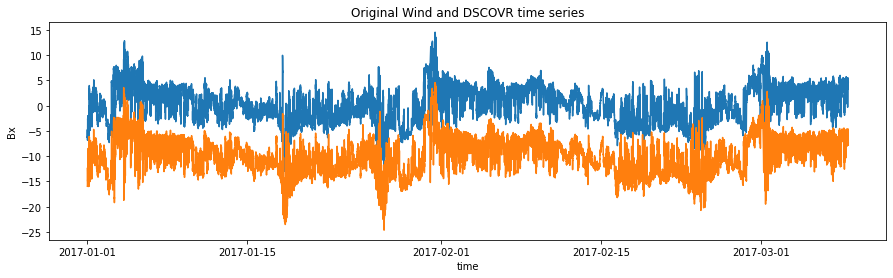

In [15]:
# Plot the two time series pre-warping. They look very similar already
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(4)

plt.plot(wdata['bx'][0:36000])  #only selecting few months of data for now
plt.title('Original Wind and DSCOVR time series')
plt.xlabel('time')
plt.ylabel('Bx')
plt.plot(ddata['bx'][0:36000]-10)


In [16]:
#reading science/traditional data with DATA Quality flags

ddata_read_science = pd.read_csv("Flagged_DSCOVR_H1_FC_2017.txt",
    delim_whitespace=True, index_col=False,comment='#', \
     header=0, parse_dates=[['DATE', 'TIME']],infer_datetime_format=True, na_values='-1.00000e+31',
    names=['DATE','TIME','DATA_QUALITY_FLAG','SW_VTH', "ION_N", "VX", "VY", "VZ"])
ddata_read_science

,DATE_TIME,DATA_QUALITY_FLAG,SW_VTH,ION_N,VX,VY,VZ
0,01-01-2017 00:00:00.000.000,0,55.8827,6.41355,-548.235,50.66970,11.93080
1,01-01-2017 00:01:00.000.000,0,49.2905,5.81441,-533.246,23.15120,16.94660
2,01-01-2017 00:02:00.000.000,0,50.0845,6.11847,-536.926,38.46060,12.65310
3,01-01-2017 00:03:00.000.000,0,49.9076,6.16366,-537.169,39.84100,9.27354
4,01-01-2017 00:04:00.000.000,0,49.6466,5.99470,-536.550,41.22870,9.16795
...,...,...,...,...,...,...,...
516956,31-12-2017 23:56:00.000.000,2,42.3851,16.45130,-401.399,-7.10588,-27.68670
516957,31-12-2017 23:57:01.000.000,2,38.9540,16.52870,-400.209,-6.69485,-28.81980
516958,31-12-2017 23:57:59.000.000,2,38.7463,16.11450,-402.689,-4.63450,-27.40180
516959,31-12-2017 23:58:59.000.000,2,39.3376,16.02150,-402.420,-7.64638,-26.55270


In [17]:
ddata_read_science['DATE_TIME'] = ddata_read_science['DATE_TIME'].astype(str)
# Now apply the string operations
ddata_read_science['DATE_TIME'] = ddata_read_science['DATE_TIME'].str.replace(r'(\d{2})\.(\d{3})$', r'\1\2', regex=True)
#ddata_read_science['DATE_TIME'] = ddata_read_science['DATE_TIME'].str.replace(r'\.(\d+)', r'\1')

# Convert to datetime
ddata_read_science['DATE_TIME'] = pd.to_datetime(ddata_read_science['DATE_TIME'], format='%d-%m-%Y %H:%M:%S.%f')
ddata_read_science['DATE_TIME']

0        2017-01-01 00:00:00
1        2017-01-01 00:01:00
2        2017-01-01 00:02:00
3        2017-01-01 00:03:00
4        2017-01-01 00:04:00
                 ...        
516956   2017-12-31 23:56:00
516957   2017-12-31 23:57:01
516958   2017-12-31 23:57:59
516959   2017-12-31 23:58:59
516960   2018-01-01 00:00:00
Name: DATE_TIME, Length: 516961, dtype: datetime64[ns]

In [19]:
ddata_read_science_drop=ddata_read_science.dropna() #deleting nan values
ddata_read_science_drop

,DATE_TIME,DATA_QUALITY_FLAG,SW_VTH,ION_N,VX,VY,VZ
0,2017-01-01 00:00:00,0,55.8827,6.41355,-548.235,50.66970,11.93080
1,2017-01-01 00:01:00,0,49.2905,5.81441,-533.246,23.15120,16.94660
2,2017-01-01 00:02:00,0,50.0845,6.11847,-536.926,38.46060,12.65310
3,2017-01-01 00:03:00,0,49.9076,6.16366,-537.169,39.84100,9.27354
4,2017-01-01 00:04:00,0,49.6466,5.99470,-536.550,41.22870,9.16795
...,...,...,...,...,...,...,...
516956,2017-12-31 23:56:00,2,42.3851,16.45130,-401.399,-7.10588,-27.68670
516957,2017-12-31 23:57:01,2,38.9540,16.52870,-400.209,-6.69485,-28.81980
516958,2017-12-31 23:57:59,2,38.7463,16.11450,-402.689,-4.63450,-27.40180
516959,2017-12-31 23:58:59,2,39.3376,16.02150,-402.420,-7.64638,-26.55270


In [20]:
# Drop rows with Flag=1-7 only keep Flag=0, Example:Flag 4= '-1.00000e+31'
ddata_read_science_drop = ddata_read_science_drop[ddata_read_science_drop['DATA_QUALITY_FLAG'] == 0]
ddata_read_science_drop

,DATE_TIME,DATA_QUALITY_FLAG,SW_VTH,ION_N,VX,VY,VZ
0,2017-01-01 00:00:00,0,55.8827,6.41355,-548.235,50.6697,11.93080
1,2017-01-01 00:01:00,0,49.2905,5.81441,-533.246,23.1512,16.94660
2,2017-01-01 00:02:00,0,50.0845,6.11847,-536.926,38.4606,12.65310
3,2017-01-01 00:03:00,0,49.9076,6.16366,-537.169,39.8410,9.27354
4,2017-01-01 00:04:00,0,49.6466,5.99470,-536.550,41.2287,9.16795
...,...,...,...,...,...,...,...
516816,2017-12-31 21:35:59,0,36.0432,8.79705,-369.636,-12.9799,-49.13580
516817,2017-12-31 21:37:00,0,35.6873,8.63787,-366.281,-10.8613,-50.81260
516818,2017-12-31 21:38:01,0,36.2122,8.96331,-364.784,-11.0948,-43.05030
516819,2017-12-31 21:38:59,0,34.5605,11.00350,-361.018,-22.3983,-34.69420


In [21]:
ddata_read_science_drop = ddata_read_science_drop.rename(columns={ddata_read_science_drop.columns[0]:"epoch", ddata_read_science_drop.columns[1]:"Flag", ddata_read_science_drop.columns[2]:"wp", ddata_read_science_drop.columns[3]:"np", ddata_read_science_drop.columns[4]:"vp"})
ddata_read_science_drop

,epoch,Flag,wp,np,vp,VY,VZ
0,2017-01-01 00:00:00,0,55.8827,6.41355,-548.235,50.6697,11.93080
1,2017-01-01 00:01:00,0,49.2905,5.81441,-533.246,23.1512,16.94660
2,2017-01-01 00:02:00,0,50.0845,6.11847,-536.926,38.4606,12.65310
3,2017-01-01 00:03:00,0,49.9076,6.16366,-537.169,39.8410,9.27354
4,2017-01-01 00:04:00,0,49.6466,5.99470,-536.550,41.2287,9.16795
...,...,...,...,...,...,...,...
516816,2017-12-31 21:35:59,0,36.0432,8.79705,-369.636,-12.9799,-49.13580
516817,2017-12-31 21:37:00,0,35.6873,8.63787,-366.281,-10.8613,-50.81260
516818,2017-12-31 21:38:01,0,36.2122,8.96331,-364.784,-11.0948,-43.05030
516819,2017-12-31 21:38:59,0,34.5605,11.00350,-361.018,-22.3983,-34.69420


In [22]:
ddata_read_science_drop = ddata_read_science_drop.resample('160s', on='epoch').median()#.bfill()
ddata_science = ddata_read_science_drop.interpolate(method="linear") #interpolation for DSCOVR data
ddata_science

,Flag,wp,np,vp,VY,VZ
epoch,,,,,,
2017-01-01 00:00:00,0.0,50.084500,6.118470,-536.926000,38.460600,12.653100
2017-01-01 00:02:40,0.0,49.646600,5.994700,-536.550000,41.228700,9.167950
2017-01-01 00:05:20,0.0,49.634450,5.888590,-536.885000,45.752650,8.223005
2017-01-01 00:08:00,0.0,48.939900,5.648020,-535.755000,40.550000,15.290600
2017-01-01 00:10:40,0.0,49.988100,5.771300,-536.160000,41.030000,14.043800
...,...,...,...,...,...,...
2017-12-31 23:49:20,0.0,39.073030,14.474642,-399.838943,-13.598177,-26.103483
2017-12-31 23:52:00,0.0,39.165123,14.545481,-400.631208,-13.418583,-25.928162
2017-12-31 23:54:40,0.0,39.257215,14.616321,-401.423472,-13.238989,-25.752842


## first step: Dynamic Time Warping

In [23]:
def DTW_function(wdata_input, ddata_input, start_index, end_index):
    
    query1_ = wdata_input.bx.values[start_index:end_index]  #WIND
    #query2 = adata.bx.values[0:3599]  #ACE
    template_ = ddata_input.bx.values[start_index:end_index] #DSCOVR as reference

    
    alignment_wd_ = dtw(query1_, template_, keep_internals=True, step_pattern=rabinerJuangStepPattern(6, "c"))
    #alignment_ad = dtw(query2, template, keep_internals=True)

    ## Display the warping curve, i.e. the alignment curve
    #alignment_wd_plot=alignment_wd.plot(type="threeway", xlab='Wind time base in minutes', ylab='DSCOVR time base in minutes', main='PLot title')
    #alignment_ad.plot(type="threeway")

    ## Align and plot with the Rabiner-Juang type VI-c unsmoothed recursion...
    
    #dtw_map=dtw(query1, template, keep_internals=True, 
        #step_pattern=rabinerJuangStepPattern(6, "c")).plot(type="twoway",xlab='nT', ylab='nT DSC',offset=-10) #blue color is the reference(DSCOVR in this case) 

    #dtw(query2, template, keep_internals=True, 
        #step_pattern=rabinerJuangStepPattern(6, "c")).plot(type="twoway",offset=-10) 

    ## See the recursion relation, as formula and diagram
    #print(rabinerJuangStepPattern(6,"c"))
    #rabinerJuangStepPattern(6,"c").plot()
    ind = warp(alignment_wd_,index_reference=False)  #indexing here #which is the indexing from the dtw part above
    
    return query1_, template_, alignment_wd_, ind

In [24]:
query1, template, alignment_wd, ind_Jan_Feb=DTW_function(wdata, ddata, 0, 36000)

Text(0.5, 1.0, 'Wind and DSCOVR Bx time series pre-warping')

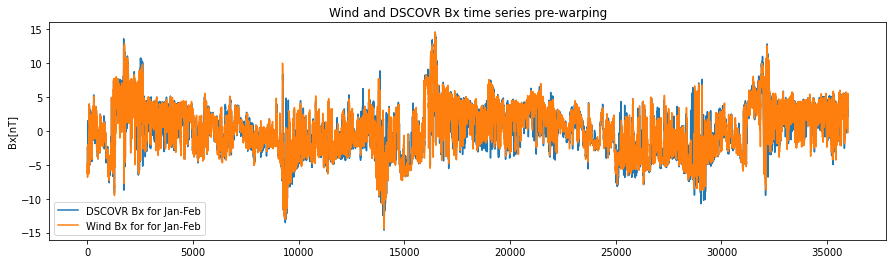

In [25]:
# plot the original Bx time series data all on top of each other
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(4)
plt.plot(template, label='DSCOVR Bx for Jan-Feb')
plt.plot(query1, label='Wind Bx for for Jan-Feb')
#plt.plot(query2)
plt.ylabel('Bx[nT]')
plt.legend()
plt.title('Wind and DSCOVR Bx time series pre-warping')

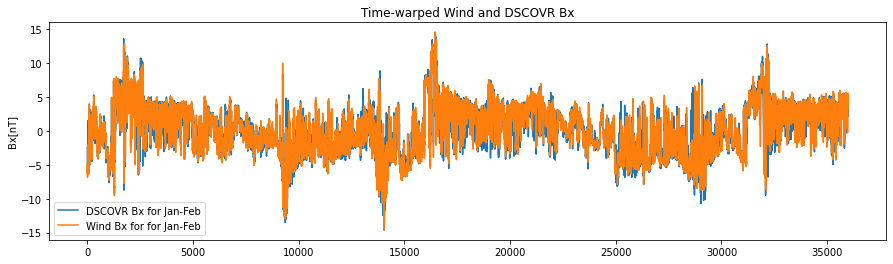

In [26]:
#replot the previous, with time warped version
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(4)
plt.plot(template, label='DSCOVR Bx for Jan-Feb') #DSCOVR
plt.plot(query1[ind_Jan_Feb], label='Wind Bx for for Jan-Feb') #Wind time-warped
plt.title('Time-warped Wind and DSCOVR Bx')
plt.legend()
#plt.plot(query2[ind2])
#plt.xlabel('time')
plt.ylabel('Bx[nT]')
plt.show()

## second step: time warping

In [27]:
def warp_function(wdata_input, ind):
    
    Wind_density_=wdata_input['Density']
    Wind_Temp_=wdata_input['Temp']
    Wind_speed_=wdata_input['Speed']

    
    warped_density_=Wind_density_[ind]  
    warped_temp_=Wind_Temp_[ind]
    warped_speed_=Wind_speed_[ind]
    return warped_density_, warped_temp_, warped_speed_

In [28]:
warped_density_Jan_Feb, warped_temp_Jan_Feb, warped_speed_Jan_Feb=warp_function(wdata, ind_Jan_Feb)

## Final part: Machine learning blackbox

In [29]:
# importing the libraries
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
print(tf.reduce_sum(tf.random.normal([1000, 1000])))
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from keras.models import load_model

tf.Tensor(-845.018, shape=(), dtype=float32)


In [30]:
#preparing the NN input data for each month

def input_prep_func(ddata_input, warped_speed, index_start, index_end):
    X = (ddata_input.iloc[:,3:53]).values  #DSCOVR data columns 3:53 as the X input
    Y = np.transpose([warped_speed]) #warped wind as the y input


    DSCOVR_input_=X[index_start:(index_end-1),:]  #DSCOVR selecting a smaller chunk to work with, Jan-Feb
    Wind_input_=Y[index_start:index_end]
    return DSCOVR_input_, Wind_input_

In [31]:
DSCOVR_input_Jan_Feb, Wind_input_Jan_Feb=input_prep_func(ddata, warped_speed_Jan_Feb, 0, 36000)

In [32]:
#Data standardization steps

def standardization_func(DSCOVR_input,  Wind_input):

    PredictorScaler=StandardScaler()
    TargetVarScaler=StandardScaler()

    # Storing the fit object for later reference
    PredictorScalerFit_=PredictorScaler.fit(DSCOVR_input)
    TargetVarScalerFit_=TargetVarScaler.fit(Wind_input)

    # Generating the standardized values of DSCOVR_input and Wind_input
    DSCOVR_input_final=PredictorScalerFit_.transform(DSCOVR_input)
    Wind_input_final=TargetVarScalerFit_.transform(Wind_input)

    # Split the data into training and testing set
    
    DSCOVR_input_train, DSCOVR_input_test, Wind_input_train, Wind_input_test = train_test_split(DSCOVR_input_final, Wind_input_final, test_size=0.3, random_state=42)

    # Quick sanity check with the shapes of Training and testing datasets
    print(DSCOVR_input_train.shape)
    print(Wind_input_train.shape)
    print(DSCOVR_input_test.shape)
    print(Wind_input_test.shape)
    
    return PredictorScalerFit_, TargetVarScalerFit_, DSCOVR_input_final, Wind_input_final, DSCOVR_input_train, DSCOVR_input_test, Wind_input_train, Wind_input_test

In [33]:
PredictorScalerFit, TargetVarScalerFit, DSCOVR_input_Jan_Feb_final, Wind_input_Jan_Feb_final, DSCOVR_input_train_Jan_Feb, DSCOVR_input_test_Jan_Feb, Wind_input_train_Jan_Feb, Wind_input_test_Jan_Feb=standardization_func(DSCOVR_input_Jan_Feb, Wind_input_Jan_Feb)

(25199, 50)
(25199, 1)
(10800, 50)
(10800, 1)


In [34]:
#custom loss function

from tensorflow.keras import backend

def mean_squared_error_func(y_true, y_pred):
    
    y_pred = tf.convert_to_tensor(y_pred)  #conver to tensor
    y_true = tf.cast(y_true, y_pred.dtype) #This line casts the y_true variable to the same data type as y_pred
    
    #scale_factor=100  #penalty factor
    squared_difference = tf.math.squared_difference(y_pred, y_true)
    penalized_squared_difference = tf.where(y_pred<1, 
                                            squared_difference**2, squared_difference)
    
    #MSE=backend.mean(tf.math.squared_difference(y_pred, y_true), axis=-1)
    #penalty = tf.nn.relu(tf.math.negative(y_pred))
    # Adjust the penalty term by scaling factor
    #scale_factor = 0.001  # Adjust this factor as needed
    #penalty *= scale_factor
    
    return backend.mean(penalized_squared_difference, axis=-1)


In [35]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix


def model_fitting_func(DSCOVR_input_train, Wind_input_train, DSCOVR_input_test, Wind_input_test):    
    # Define the regression model
    regression_model = Sequential()
    regression_model.add(Dense(units=8, input_dim=50, kernel_initializer='normal', activation='relu'))
    regression_model.add(Dense(units=8, kernel_initializer='normal', activation='relu'))
    regression_model.add(Dense(1, kernel_initializer='normal', name='regression_output'))
    regression_model.compile(loss='mean_squared_error_func', optimizer='adam')
    
    
    # Train the regression model
    regression_model.fit(DSCOVR_input_train, Wind_input_train, batch_size=20, epochs=50, verbose=1)

    regression_model.save('regression_model')
    
    Jan_Feb_regression_model = load_model('regression_model')
    
    predictions_regression_ = Jan_Feb_regression_model.predict(DSCOVR_input_test)
    
    # Scaling the predicted data back to the original scale
    predictions_regression = TargetVarScalerFit.inverse_transform(predictions_regression_)
    Wind_input_test_orig = TargetVarScalerFit.inverse_transform(Wind_input_test)
    Test_Data = PredictorScalerFit.inverse_transform(DSCOVR_input_test)

    TestingData_ = pd.DataFrame(data=Test_Data)
    TestingData_['GT'] = Wind_input_test_orig
    TestingData_['Predicted'] = predictions_regression
    
    # Computing the absolute percent error
    APE = 100 * (abs(TestingData_['GT'] - TestingData_['Predicted']) / TestingData_['GT'])
    TestingData_['APE'] = APE
    
    print('The Accuracy of Regression model is:', 100 - np.mean(APE))
    
    
    
    return Jan_Feb_regression_model, predictions_regression, TestingData_['GT'], TestingData_['Predicted'] 

     
# Register custom loss function
tf.keras.utils.get_custom_objects()['mean_squared_error_func'] = mean_squared_error_func

In [36]:
Jan_feb_model, predictions_Jan_feb, TestingData_GT, TestingData_Predicted=model_fitting_func(DSCOVR_input_train_Jan_Feb, Wind_input_train_Jan_Feb, DSCOVR_input_test_Jan_Feb, Wind_input_test_Jan_Feb)

Epoch 1/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.1180
Epoch 2/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0513
Epoch 3/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0403
Epoch 4/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0320
Epoch 5/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0214
Epoch 6/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0163
Epoch 7/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0134
Epoch 8/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0147
Epoch 9/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0111
Epoch 10/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0157
Epoch 11/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0101
Epoch 12/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0115
E

In [39]:
mask=(TestingData_Predicted >= 1) &(TestingData_Predicted<=850)
TestingData_Predicted=TestingData_Predicted[mask]
TestingData_GT=TestingData_GT[mask]

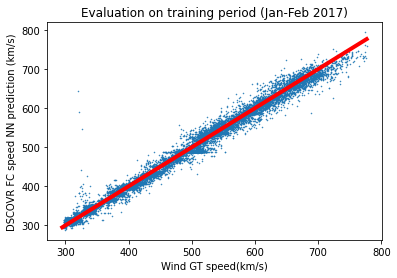

In [40]:
plt.plot(TestingData_GT, TestingData_Predicted, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation on training period (Jan-Feb 2017)')
#plt.xlim(np.amin(TestingData_GT), np.amax(TestingData_GT))
#plt.ylim(np.amin(TestingData_GT), np.amax(TestingData_GT))
plt.plot([np.amin(TestingData_GT), np.amax(TestingData_GT)],[np.amin(TestingData_GT), np.amax(TestingData_GT)], color='red', linewidth=4)
plt.savefig('speed-Jan-Feb_prediction_2017.png')

Mean err %:  10.717795972539875
Median err %:  8.10069384765626
Most probable err %:  11.963692626953105
stddev: 15.135217931928809


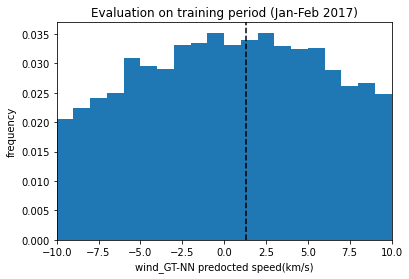

In [41]:
perr_NN = 100.*(TestingData_GT-TestingData_Predicted)/TestingData_GT
tk_NN=np.where(TestingData_GT > 0.1)
arr_perr_NN = (perr_NN.values)[tk_NN]

arr_regular_NN=(TestingData_GT-TestingData_Predicted)


sd_NN=statistics.stdev((arr_regular_NN))
m_NN=statistics.mean((arr_regular_NN))

plt.hist(arr_regular_NN, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN, color='k', linestyle='dashed')
plt.axvline(m_NN+sd_NN, color='y', linestyle='dashed')
plt.axvline(m_NN-sd_NN, color='y', linestyle='dashed')

plt.xlim(-10,10)
#plt.yscale('log')
plt.title('Evaluation on training period (Jan-Feb 2017)')
plt.xlabel('wind_GT-NN predocted speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-Jan-Feb_prediction_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_NN)))
print('Median err %: ', np.median(abs(arr_regular_NN)))
print('Most probable err %: ', statistics.mode(abs(arr_regular_NN)))

print('stddev:',sd_NN)

## science data comparison

In [42]:
DSCOVR_science_Jan_Feb=np.abs(ddata_science['vp'][0:35999])
DSCOVR_science_March=np.abs(ddata_science['vp'][36000: 48999])
DSCOVR_science_April=np.abs(ddata_science['vp'][49000: 64999])
DSCOVR_science_May=np.abs(ddata_science['vp'][65000: 80999])
DSCOVR_science_June=np.abs(ddata_science['vp'][81000: 97999])
DSCOVR_science_July=np.abs(ddata_science['vp'][98000: 113999])
DSCOVR_science_August=np.abs(ddata_science['vp'][114000:130999])
DSCOVR_science_September=np.abs(ddata_science['vp'][131000: 145999])
DSCOVR_science_October=np.abs(ddata_science['vp'][146000:163999])
DSCOVR_science_November=np.abs(ddata_science['vp'][164000: 179999])
DSCOVR_science_December=np.abs(ddata_science['vp'][180000: 197099])

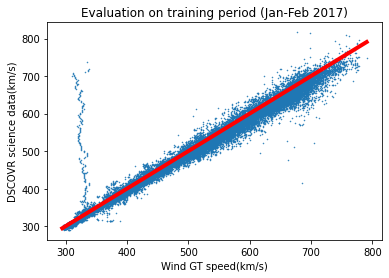

In [43]:
plt.plot(warped_speed_Jan_Feb, DSCOVR_science_Jan_Feb, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR science data(km/s)")
plt.title('Evaluation on training period (Jan-Feb 2017)')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(warped_speed_Jan_Feb), np.amax(warped_speed_Jan_Feb)],[np.amin(warped_speed_Jan_Feb), np.amax(warped_speed_Jan_Feb)], color='red', linewidth=4)

plt.savefig('speed-Jan-Feb_science_2017.png')

In [44]:
ww=warped_speed_Jan_Feb  #Jan-Feb Wind speed
dd=np.abs(ddata_science['vp'][0:35999]) #Jan-Feb DSCOVR speed

Mean err %:  11.64303094280206
Median err %:  7.290999999999997
Most probable err %:  10.158999999999992
stddev: 21.055765749617947


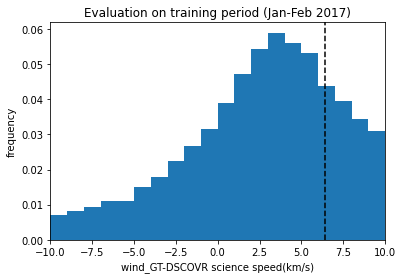

In [45]:
perr_science = 100.*(ww.values-dd.values)/ww.values
tk_science=np.where((ww.values > 0.1) & ((ww.values-dd.values)!=0))

arr_perr_science = (perr_science)[tk_science]

arr_regular_science=((ww.values-dd.values))[tk_science]

sd_regular_science=statistics.stdev((arr_regular_science))
m_regular_science=statistics.mean((arr_regular_science))

plt.hist(arr_regular_science, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science, color='k', linestyle='dashed')
plt.axvline(m_regular_science+sd_regular_science, color='y', linestyle='dashed')
plt.axvline(m_regular_science-sd_regular_science, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.title('Evaluation on training period (Jan-Feb 2017)')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-Jan-Feb_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science)))
print('Median err %: ', np.median(abs(arr_regular_science)))
print('Most probable err %: ', statistics.mode(abs(arr_regular_science)))

print('stddev:',sd_regular_science)

### Beyond training period

## March

In [46]:
def non_warped_values_func(wdata_input):
    
    Wind_density_=wdata_input['Density']
    Wind_Temp_=wdata_input['Temp']
    Wind_speed_=wdata_input['Speed']

    return Wind_density_, Wind_Temp_, Wind_speed_

In [47]:
Wind_density, Wind_Temp, Wind_speed=non_warped_values_func(wdata)

DSCOVR_input_March, Wind_input_March=input_prep_func(ddata, Wind_speed.values, 36000, 49000)
query1_March, template_March, alignment_wd_March, ind_March=DTW_function(wdata, ddata, 36000, 49000)
Wind_input_March_warped=Wind_input_March[ind_March]

In [48]:
DSCOVR_input_March_final=PredictorScalerFit.transform(DSCOVR_input_March)

Jan_feb_model, Predictions_March, Wing_GT_March, Testing_Predictions_March=model_fitting_func(DSCOVR_input_train_Jan_Feb, Wind_input_train_Jan_Feb, DSCOVR_input_March_final, Wind_input_March_warped)

Epoch 1/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.1337
Epoch 2/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0540
Epoch 3/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0430
Epoch 4/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0302
Epoch 5/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0250
Epoch 6/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0196
Epoch 7/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0176
Epoch 8/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0221
Epoch 9/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0137
Epoch 10/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0174
Epoch 11/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0135
Epoch 12/50
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0120
E

In [49]:
mask_March=(Predictions_March >= 1) & (Predictions_March<=850)
Predictions_March=Predictions_March[mask_March]
Wind_input_March_warped=Wind_input_March_warped[mask_March]

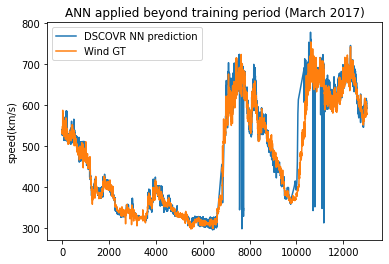

In [50]:
plt.plot(Predictions_March, label='DSCOVR NN prediction')
plt.plot(Wind_input_March_warped, label='Wind GT')
plt.title('ANN applied beyond training period (March 2017)')
plt.savefig('speed_March_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

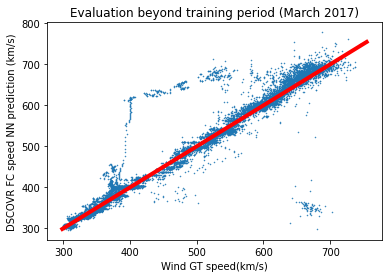

In [51]:
plt.plot(Wind_input_March_warped, Predictions_March, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (March 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped)],[np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped)], color='red', linewidth=4)
plt.savefig('speed-March_prediction_2017.png')

Mean err %:  15.786973492996458
Median err %:  6.975569824218724
stddev: 38.23923616983465


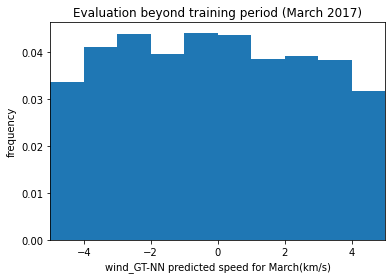

In [52]:
perr_NN_March = 100.*(Wind_input_March_warped-Predictions_March)/Wind_input_March_warped
tk_NN_March=np.where(Wind_input_March_warped > 0.1)
arr_perr_NN_March = (perr_NN_March)[tk_NN_March]
arr_regular_NN_March=(Wind_input_March_warped-Predictions_March)
m_NN_March=np.mean((arr_regular_NN_March))
sd_NN_March=np.std((arr_regular_NN_March))


plt.hist(arr_regular_NN_March, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_March, color='k', linestyle='dashed')
plt.axvline(m_NN_March+sd_NN_March, color='y', linestyle='dashed')
plt.axvline(m_NN_March-sd_NN_March, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.title('Evaluation beyond training period (March 2017)')
plt.xlabel('wind_GT-NN predicted speed for March(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-March_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_March)))
print('Median err %: ', np.median(abs(arr_regular_NN_March)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_March)

## comparison with science data for March

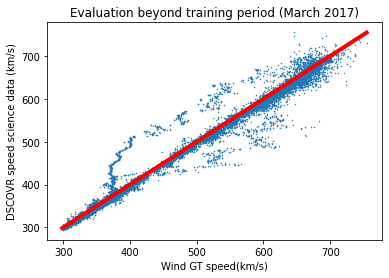

In [53]:
plt.plot(Wind_input_March_warped, DSCOVR_science_March[mask_March.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR speed science data (km/s)")
plt.title('Evaluation beyond training period (March 2017)')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped)],[np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped)], color='red', linewidth=4)

plt.savefig('speed-March_science_2017.png')

Mean err %:  144.5077547671264
Median err %:  127.88066666666668
stddev: 179.73326968675704


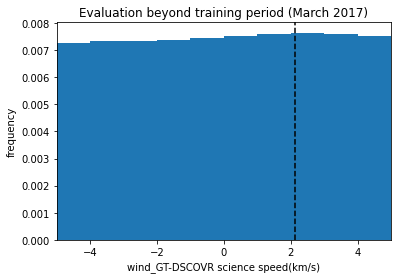

In [54]:
DSCOVR_science_March=np.transpose([np.abs(ddata_science['vp'][36000: 48999])]) #March DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_March=np.where((Wind_input_March_warped > 0.1) & ((Wind_input_March_warped-DSCOVR_science_March)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_March=((Wind_input_March_warped-DSCOVR_science_March))[tk_science_March]
m_regular_science_March=np.mean((arr_regular_science_March))
sd_regular_science_March=np.std((arr_regular_science_March))

plt.hist(arr_regular_science_March, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_March, color='k', linestyle='dashed')
plt.axvline(m_regular_science_March+sd_regular_science_March, color='y', linestyle='dashed')
plt.axvline(m_regular_science_March-sd_regular_science_March, color='y', linestyle='dashed')


plt.xlim(-5,5)
#plt.yscale('log')
plt.title('Evaluation beyond training period (March 2017)' )
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-March_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_March)))
print('Median err %: ', np.median(abs(arr_regular_science_March)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_March)

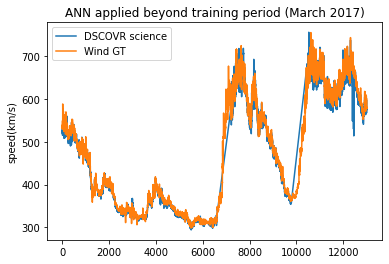

In [55]:
plt.plot(DSCOVR_science_March, label='DSCOVR science')
plt.plot(Wind_input_March_warped, label='Wind GT')
plt.title('ANN applied beyond training period (March 2017)')
plt.savefig('speed_March_DSCOVR_science_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

## April

In [56]:
DSCOVR_input_April, Wind_input_April=input_prep_func(ddata, Wind_speed.values, 49000, 65000)
query1_April, template_April, alignment_wd_April, ind_April=DTW_function(wdata, ddata, 49000, 65000)
Wind_input_April_warped=Wind_input_April[ind_April]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_March_final=PredictorScalerFit.transform(DSCOVR_input_March)


Wind_input_March_warped=Wind_input_March_warped.reshape(-1,1)
Wind_input_March_warped_final=TargetVarScalerFit.transform(Wind_input_March_warped)

mask_March_flat = mask_March.flatten()

# Now use the flattened mask for indexing
DSCOVR_input_March_final = DSCOVR_input_March_final[mask_March_flat]



opt = keras.optimizers.Adam(learning_rate=1e-5)
Jan_feb_model.compile(loss='mean_squared_error', optimizer=opt)


Jan_feb_model.fit(DSCOVR_input_March_final, Wind_input_March_warped_final, batch_size = 20, epochs = 50, verbose=1)
Jan_feb_model.save('saved_model_March')

March_model = load_model('saved_model_March')



# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_April_final=PredictorScalerFit.transform(DSCOVR_input_April)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_April_regression_ = March_model.predict(DSCOVR_input_April_final)

# Scaling the data back to original scale for regression predictions
Predictions_April_regression = TargetVarScalerFit.inverse_transform(Predictions_April_regression_)

Epoch 1/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0990
Epoch 2/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0896
Epoch 3/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0848
Epoch 4/50
650/650 [==============================] - 3s 5ms/step - loss: 0.0814
Epoch 5/50
650/650 [==============================] - 3s 5ms/step - loss: 0.0785
Epoch 6/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0759
Epoch 7/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0733
Epoch 8/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0709
Epoch 9/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0686
Epoch 10/50
650/650 [==============================] - 3s 4ms/step - loss: 0.0664
Epoch 11/50
650/650 [==============================] - 3s 5ms/step - loss: 0.0642
Epoch 12/50
650/650 [==============================] - 3s 5ms/step - loss: 0.0621
Epoch 13/50
650/650 [====

650/650 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 40/50
650/650 [==============================] - 4s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 41/50
650/650 [==============================] - 4s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 42/50
650/650 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 43/50
650/650 [==============================] - 4s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 44/50
650/650 [==============================] - 4s 7ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 45/50
650/650 [==============================] - 4s 7ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 46/50
650/650 [==============================] - 4s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 47/50
650/650 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 48/50
650/650 [==============================] - 4s 6ms/step 

In [58]:
mask_April=(Predictions_April_regression >= 1) & (Predictions_April_regression<=850)
Predictions_April=Predictions_April_regression[mask_April]
Wind_input_April_warped=Wind_input_April_warped[mask_April]

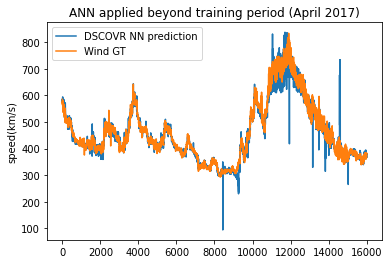

In [59]:
plt.plot(Predictions_April, label='DSCOVR NN prediction')
plt.plot(Wind_input_April_warped, label='Wind GT')
plt.title('ANN applied beyond training period (April 2017)')
plt.savefig('speed_April_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

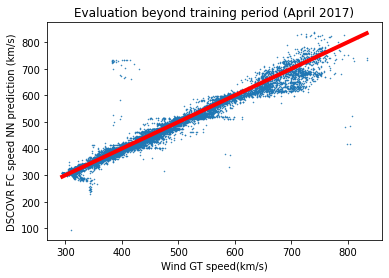

In [60]:
plt.plot(Wind_input_April_warped, Predictions_April, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (April 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_April_warped), np.amax(Wind_input_April_warped)],[np.amin(Wind_input_April_warped), np.amax(Wind_input_April_warped)], color='red', linewidth=4)
plt.savefig('speed-April_prediction_2017.png')

Mean err %:  12.903993553332239
Median err %:  7.785615234374973
stddev: 23.901204806673498


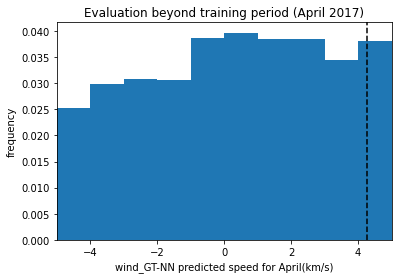

In [61]:
perr_NN_April = 100.*(Wind_input_April_warped-Predictions_April)/Wind_input_April_warped
tk_NN_April=np.where(Wind_input_April_warped > 0.1)
arr_perr_NN_April = (perr_NN_April)[tk_NN_April]
arr_regular_NN_April=(Wind_input_April_warped-Predictions_April)
m_NN_April=np.mean((arr_regular_NN_April))
sd_NN_April=np.std((arr_regular_NN_April))


plt.hist(arr_regular_NN_April, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_April, color='k', linestyle='dashed')
plt.axvline(m_NN_April+sd_NN_April, color='y', linestyle='dashed')
plt.axvline(m_NN_April-sd_NN_April, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.title('Evaluation beyond training period (April 2017)')
plt.xlabel('wind_GT-NN predicted speed for April(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-April_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_April)))
print('Median err %: ', np.median(abs(arr_regular_NN_April)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_April)

## comparison with science data for April

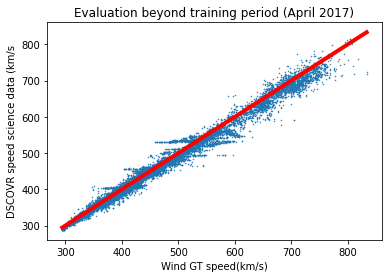

In [62]:
plt.plot(Wind_input_April_warped, DSCOVR_science_April[mask_April.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation beyond training period (April 2017)')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_April_warped), np.amax(Wind_input_April_warped)],[np.amin(Wind_input_April_warped), np.amax(Wind_input_April_warped)], color='red', linewidth=4)

plt.savefig('speed-April_science_2017.png')

Mean err %:  117.3648164385219
Median err %:  90.47749999999996
stddev: 151.83945204310078


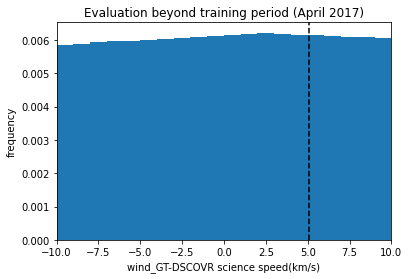

In [63]:
DSCOVR_science_April=np.transpose([np.abs(ddata_science['vp'][49000: 64999])]) #April DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_April=np.where((Wind_input_April_warped > 0.1) & ((Wind_input_April_warped-DSCOVR_science_April)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_April=((Wind_input_April_warped-DSCOVR_science_April))[tk_science_April]
m_regular_science_April=np.mean((arr_regular_science_April))
sd_regular_science_April=np.std((arr_regular_science_April))

plt.hist(arr_regular_science_April, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_April, color='k', linestyle='dashed')
plt.axvline(m_regular_science_April+sd_regular_science_April, color='y', linestyle='dashed')
plt.axvline(m_regular_science_April-sd_regular_science_April, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.title('Evaluation beyond training period (April 2017)')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-April_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_April)))
print('Median err %: ', np.median(abs(arr_regular_science_April)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_April)

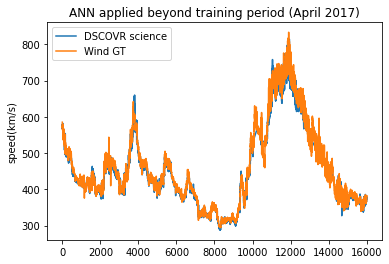

In [64]:
#DSCOVR_input_March_final=PredictorScalerFit.transform(DSCOVR_input_March)
#Predictions_March=model.predict(DSCOVR_input_March_final)
#Predictions_March=TargetVarScalerFit.inverse_transform(Predictions_March)


plt.plot(DSCOVR_science_April, label='DSCOVR science')
plt.plot(Wind_input_April_warped, label='Wind GT')
plt.title('ANN applied beyond training period (April 2017)')
plt.savefig('speed_April_DSCOVR_science_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

## May

In [65]:
## May

DSCOVR_input_May, Wind_input_May=input_prep_func(ddata, Wind_speed.values, 65000, 81000)
query1_May, template_May, alignment_wd_May, ind_May=DTW_function(wdata, ddata, 65000, 81000)
Wind_input_May_warped=Wind_input_May[ind_May]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_April_final=PredictorScalerFit.transform(DSCOVR_input_April)



Wind_input_April_warped=Wind_input_April_warped.reshape(-1,1)
Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)


mask_April_flat = mask_April.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_April_final = DSCOVR_input_April_final[mask_April_flat]



#18 is the best so far
opt_2 = keras.optimizers.Adam(learning_rate=1e-16)
March_model.compile(loss='mean_squared_error', optimizer=opt_2)


March_model.fit(DSCOVR_input_April_final, Wind_input_April_warped_final, batch_size = 20, epochs = 50, verbose=1)
March_model.save('saved_model_April')

April_model = load_model('saved_model_April')   



# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_May_final=PredictorScalerFit.transform(DSCOVR_input_May)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_May_regression_ = April_model.predict(DSCOVR_input_May_final)

# Scaling the data back to original scale for regression predictions
Predictions_May_regression = TargetVarScalerFit.inverse_transform(Predictions_May_regression_)


Epoch 1/50
800/800 [==============================] - 4s 4ms/step - loss: 0.0424
Epoch 2/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 3/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 4/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 5/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 6/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 7/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 8/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 9/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 10/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 11/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 12/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0424
Epoch 13/50
800/800 [====

800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 40/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 41/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 42/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 43/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 44/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 45/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 46/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 47/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 48/50
800/800 [==============================] - 4s 5ms/step 

In [67]:
mask_May=(Predictions_May_regression >= 1) & (Predictions_May_regression<=850)
Predictions_May=Predictions_May_regression[mask_May]
Wind_input_May_warped=Wind_input_May_warped[mask_May]

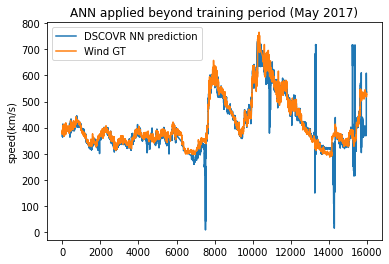

In [68]:
plt.plot(Predictions_May, label='DSCOVR NN prediction')
plt.plot(Wind_input_May_warped, label='Wind GT')
plt.title('ANN applied beyond training period (May 2017)')
plt.savefig('speed_May_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

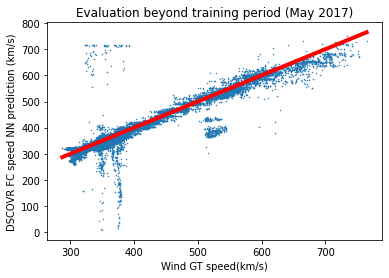

In [69]:
plt.plot(Wind_input_May_warped, Predictions_May, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (May 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_May_warped), np.amax(Wind_input_May_warped)],[np.amin(Wind_input_May_warped), np.amax(Wind_input_May_warped)], color='red', linewidth=4)
plt.savefig('speed-May_prediction_2017.png')

Mean err %:  16.99483553962707
Median err %:  9.134396606445307
stddev: 36.9941324015263


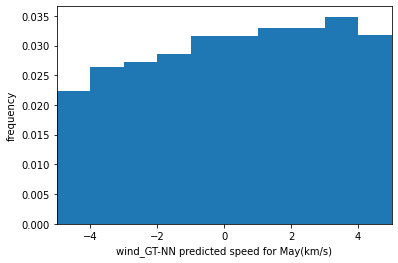

In [70]:
perr_NN_May = 100.*(Wind_input_May_warped-Predictions_May)/Wind_input_May_warped
tk_NN_May=np.where(Wind_input_May_warped > 0.1)
arr_perr_NN_May = (perr_NN_May)[tk_NN_May]
arr_regular_NN_May=(Wind_input_May_warped-Predictions_May)
m_NN_May=np.mean((arr_regular_NN_May))
sd_NN_May=np.std((arr_regular_NN_May))


plt.hist(arr_regular_NN_May, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_May, color='k', linestyle='dashed')
plt.axvline(m_NN_May+sd_NN_May, color='y', linestyle='dashed')
plt.axvline(m_NN_May-sd_NN_May, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for May(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-May_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_May)))
print('Median err %: ', np.median(abs(arr_regular_NN_May)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_May)

## comparison with science data for May

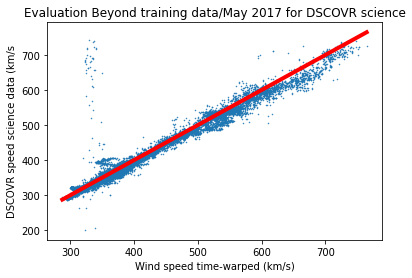

In [71]:
plt.plot(Wind_input_May_warped, DSCOVR_science_May[mask_May.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/May 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_May_warped), np.amax(Wind_input_May_warped)],[np.amin(Wind_input_May_warped), np.amax(Wind_input_May_warped)], color='red', linewidth=4)

plt.savefig('speed-May_science_2017.png')

Mean err %:  97.7251734920995
Median err %:  67.80450000000002
stddev: 130.90724443539025


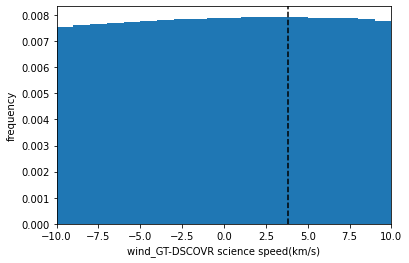

In [72]:
DSCOVR_science_May=np.transpose([np.abs(ddata_science['vp'][65000: 80999])]) #May DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_May=np.where((Wind_input_May_warped > 0.1) & ((Wind_input_May_warped-DSCOVR_science_May)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_May=((Wind_input_May_warped-DSCOVR_science_May))[tk_science_May]
m_regular_science_May=np.mean((arr_regular_science_May))
sd_regular_science_May=np.std((arr_regular_science_May))

plt.hist(arr_regular_science_May, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_May, color='k', linestyle='dashed')
plt.axvline(m_regular_science_May+sd_regular_science_May, color='y', linestyle='dashed')
plt.axvline(m_regular_science_May-sd_regular_science_May, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-May_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_May)))
print('Median err %: ', np.median(abs(arr_regular_science_May)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_May)

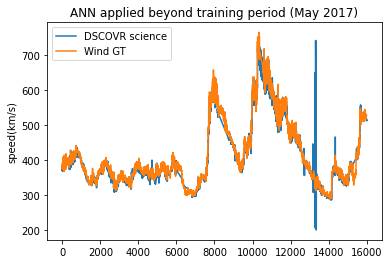

In [73]:
#DSCOVR_input_March_final=PredictorScalerFit.transform(DSCOVR_input_March)
#Predictions_March=model.predict(DSCOVR_input_March_final)
#Predictions_March=TargetVarScalerFit.inverse_transform(Predictions_March)


plt.plot(DSCOVR_science_May, label='DSCOVR science')
plt.plot(Wind_input_May_warped, label='Wind GT')
plt.title('ANN applied beyond training period (May 2017)')
plt.savefig('speed_May_DSCOVR_science_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

## June

In [74]:
## June

DSCOVR_input_June, Wind_input_June=input_prep_func(ddata, Wind_speed.values, 81000, 98000)
query1_June, template_June, alignment_wd_June, ind_June=DTW_function(wdata, ddata, 81000, 98000)
Wind_input_June_warped=Wind_input_June[ind_June]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_May_final=PredictorScalerFit.transform(DSCOVR_input_May)


Wind_input_May_warped=Wind_input_May_warped.reshape(-1,1)
Wind_input_May_warped_final=TargetVarScalerFit.transform(Wind_input_May_warped)

mask_May_flat = mask_May.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_May_final = DSCOVR_input_May_final[mask_May_flat]


#18 is the best so far
opt_3 = keras.optimizers.Adam(learning_rate=1e-19)
April_model.compile(loss='mean_squared_error', optimizer=opt_3)


April_model.fit(DSCOVR_input_May_final, Wind_input_May_warped_final, batch_size = 20, epochs = 50, verbose=1)
April_model.save('saved_model_May')

May_model = load_model('saved_model_May')






# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_June_final=PredictorScalerFit.transform(DSCOVR_input_June)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_June_regression_ = May_model.predict(DSCOVR_input_June_final)

# Scaling the data back to original scale for regression predictions
Predictions_June_regression = TargetVarScalerFit.inverse_transform(Predictions_June_regression_)


Epoch 1/50
800/800 [==============================] - 4s 4ms/step - loss: 0.1022
Epoch 2/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 3/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 4/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 5/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 6/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 7/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 8/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 9/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 10/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 11/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 12/50
800/800 [==============================] - 3s 4ms/step - loss: 0.1022
Epoch 13/50
800/800 [====

In [76]:
mask_June=(Predictions_June_regression >= 1) & (Predictions_June_regression<=850)
Predictions_June=Predictions_June_regression[mask_June]
Wind_input_June_warped=Wind_input_June_warped[mask_June]

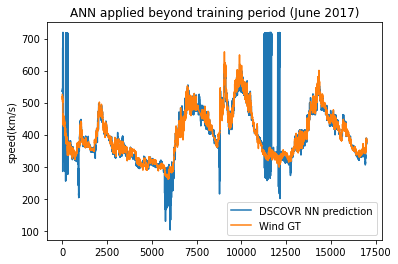

In [77]:
plt.plot(Predictions_June, label='DSCOVR NN prediction')
plt.plot(Wind_input_June_warped, label='Wind GT')
plt.title('ANN applied beyond training period (June 2017)')
plt.savefig('speed_June_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

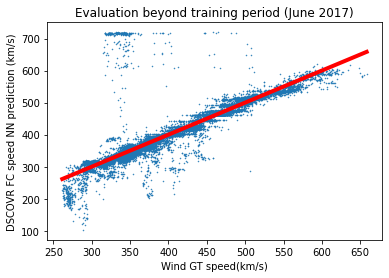

In [78]:
plt.plot(Wind_input_June_warped, Predictions_June, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (June 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_June_warped), np.amax(Wind_input_June_warped)],[np.amin(Wind_input_June_warped), np.amax(Wind_input_June_warped)], color='red', linewidth=4)
plt.savefig('speed-June_prediction_2017.png')

Mean err %:  17.37992767838515
Median err %:  7.307292114257791
stddev: 50.20523913469306


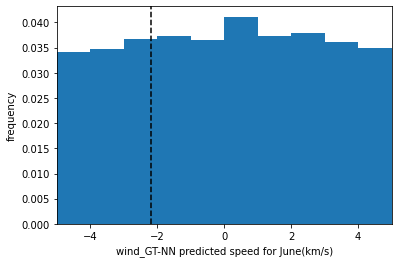

In [79]:
perr_NN_June = 100.*(Wind_input_June_warped-Predictions_June)/Wind_input_June_warped
tk_NN_June=np.where(Wind_input_June_warped > 0.1)
arr_perr_NN_June = (perr_NN_June)[tk_NN_June]
arr_regular_NN_June=(Wind_input_June_warped-Predictions_June)
m_NN_June=np.mean((arr_regular_NN_June))
sd_NN_June=np.std((arr_regular_NN_June))


plt.hist(arr_regular_NN_June, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_June, color='k', linestyle='dashed')
plt.axvline(m_NN_June+sd_NN_June, color='y', linestyle='dashed')
plt.axvline(m_NN_June-sd_NN_June, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for June(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-June_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_June)))
print('Median err %: ', np.median(abs(arr_regular_NN_June)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_June)

## comparison with science data for June

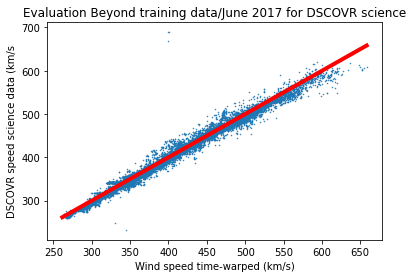

In [80]:
plt.plot(Wind_input_June_warped, DSCOVR_science_June[mask_June.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/June 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_June_warped), np.amax(Wind_input_June_warped)],[np.amin(Wind_input_June_warped), np.amax(Wind_input_June_warped)], color='red', linewidth=4)

plt.savefig('speed-June_science_2017.png')

Mean err %:  82.10986099355938
Median err %:  69.12200000000007
stddev: 102.95394579799637


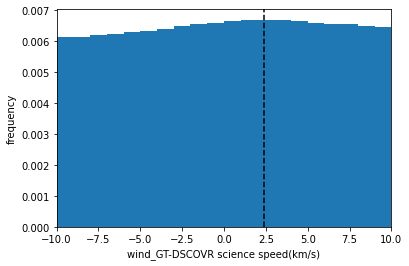

In [81]:
DSCOVR_science_June=np.transpose([np.abs(ddata_science['vp'][81000: 97999])]) #May DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_June=np.where((Wind_input_June_warped > 0.1) & ((Wind_input_June_warped-DSCOVR_science_June)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_June=((Wind_input_June_warped-DSCOVR_science_June))[tk_science_June]
m_regular_science_June=np.mean((arr_regular_science_June))
sd_regular_science_June=np.std((arr_regular_science_June))

plt.hist(arr_regular_science_June, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_June, color='k', linestyle='dashed')
plt.axvline(m_regular_science_June+sd_regular_science_June, color='y', linestyle='dashed')
plt.axvline(m_regular_science_June-sd_regular_science_June, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-June_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_June)))
print('Median err %: ', np.median(abs(arr_regular_science_June)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_June)

## July

In [82]:
## July

DSCOVR_input_July, Wind_input_July=input_prep_func(ddata, Wind_speed.values, 98000, 114000)
query1_July, template_July, alignment_wd_July, ind_July=DTW_function(wdata, ddata, 98000, 114000)
Wind_input_July_warped=Wind_input_July[ind_July]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_June_final=PredictorScalerFit.transform(DSCOVR_input_June)


Wind_input_June_warped=Wind_input_June_warped.reshape(-1,1)
Wind_input_June_warped_final=TargetVarScalerFit.transform(Wind_input_June_warped)

mask_June_flat = mask_June.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_June_final = DSCOVR_input_June_final[mask_June_flat]


#18 is the best so far
opt_4 = keras.optimizers.Adam(learning_rate=1e-26)
May_model.compile(loss='mean_squared_error', optimizer=opt_4)

May_model.fit(DSCOVR_input_June_final, Wind_input_June_warped_final, batch_size = 20, epochs = 50, verbose=1)
May_model.save('saved_model_June')

June_model = load_model('saved_model_June')







# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_July_final=PredictorScalerFit.transform(DSCOVR_input_July)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_July_regression_ = June_model.predict(DSCOVR_input_July_final)

# Scaling the data back to original scale for regression predictions
Predictions_July_regression = TargetVarScalerFit.inverse_transform(Predictions_July_regression_)



Epoch 1/50
850/850 [==============================] - 4s 4ms/step - loss: 0.1815
Epoch 2/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 3/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 4/50
850/850 [==============================] - 4s 4ms/step - loss: 0.1815
Epoch 5/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 6/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 7/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 8/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 9/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 10/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 11/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 12/50
850/850 [==============================] - 3s 4ms/step - loss: 0.1815
Epoch 13/50
850/850 [====

In [84]:
mask_July=(Predictions_July_regression >= 1) & (Predictions_July_regression<=850)
Predictions_July=Predictions_July_regression[mask_July]
Wind_input_July_warped=Wind_input_July_warped[mask_July]

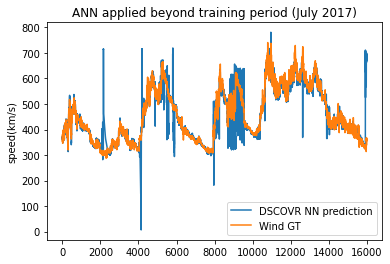

In [85]:
plt.plot(Predictions_July, label='DSCOVR NN prediction')
plt.plot(Wind_input_July_warped, label='Wind GT')
plt.title('ANN applied beyond training period (July 2017)')
plt.savefig('speed_July_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

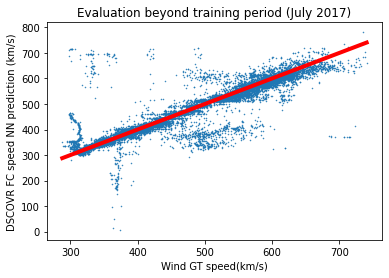

In [86]:
plt.plot(Wind_input_July_warped, Predictions_July, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (July 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_July_warped), np.amax(Wind_input_July_warped)],[np.amin(Wind_input_July_warped), np.amax(Wind_input_July_warped)], color='red', linewidth=4)
plt.savefig('speed-July_prediction_2017.png')

Mean err %:  19.63337467220299
Median err %:  8.002997924804674
stddev: 43.5919273423902


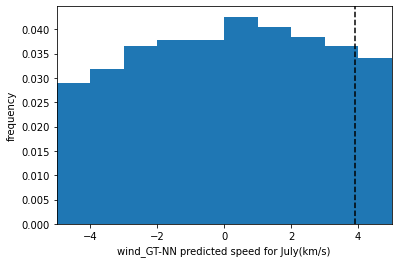

In [87]:
perr_NN_July = 100.*(Wind_input_July_warped-Predictions_July)/Wind_input_July_warped
tk_NN_July=np.where(Wind_input_July_warped > 0.1)
arr_perr_NN_July = (perr_NN_July)[tk_NN_July]
arr_regular_NN_July=(Wind_input_July_warped-Predictions_July)
m_NN_July=np.mean((arr_regular_NN_July))
sd_NN_July=np.std((arr_regular_NN_July))


plt.hist(arr_regular_NN_July, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_July, color='k', linestyle='dashed')
plt.axvline(m_NN_July+sd_NN_July, color='y', linestyle='dashed')
plt.axvline(m_NN_July-sd_NN_July, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for July(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-July_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_July)))
print('Median err %: ', np.median(abs(arr_regular_NN_July)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_July)

## comparison with science data for July

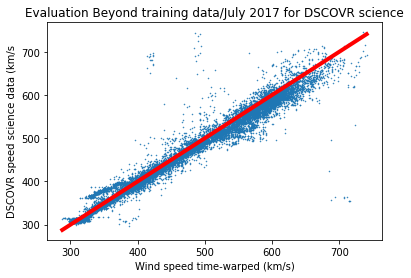

In [88]:
plt.plot(Wind_input_July_warped, DSCOVR_science_July[mask_July.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/July 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_July_warped), np.amax(Wind_input_July_warped)],[np.amin(Wind_input_July_warped), np.amax(Wind_input_July_warped)], color='red', linewidth=4)

plt.savefig('speed-July_science_2017.png')

Mean err %:  114.43913878240491
Median err %:  97.64550000000003
stddev: 141.51823280467445


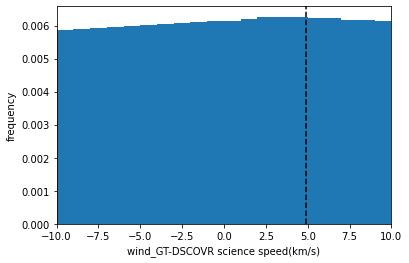

In [89]:
DSCOVR_science_July=np.transpose([np.abs(ddata_science['vp'][98000: 113999])]) #May DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_July=np.where((Wind_input_July_warped > 0.1) & ((Wind_input_July_warped-DSCOVR_science_July)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_July=((Wind_input_July_warped-DSCOVR_science_July))[tk_science_July]
m_regular_science_July=np.mean((arr_regular_science_July))
sd_regular_science_July=np.std((arr_regular_science_July))

plt.hist(arr_regular_science_July, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_July, color='k', linestyle='dashed')
plt.axvline(m_regular_science_July+sd_regular_science_July, color='y', linestyle='dashed')
plt.axvline(m_regular_science_July-sd_regular_science_July, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-July_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_July)))
print('Median err %: ', np.median(abs(arr_regular_science_July)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_July)

## August

In [90]:
## August

DSCOVR_input_August, Wind_input_August=input_prep_func(ddata, Wind_speed.values, 114000, 131000)
query1_August, template_August, alignment_wd_August, ind_August=DTW_function(wdata, ddata, 114000, 131000)
Wind_input_August_warped=Wind_input_August[ind_August]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_July_final=PredictorScalerFit.transform(DSCOVR_input_July)


Wind_input_July_warped=Wind_input_July_warped.reshape(-1,1)
Wind_input_July_warped_final=TargetVarScalerFit.transform(Wind_input_July_warped)

mask_July_flat = mask_July.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_July_final = DSCOVR_input_July_final[mask_July_flat]



#18 is the best so far
opt_5 = keras.optimizers.Adam(learning_rate=1e-32)
June_model.compile(loss='mean_squared_error', optimizer=opt_5)

June_model.fit(DSCOVR_input_July_final, Wind_input_July_warped_final, batch_size = 20, epochs = 50, verbose=1)
June_model.save('saved_model_July')

July_model = load_model('saved_model_July')







# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_August_final=PredictorScalerFit.transform(DSCOVR_input_August)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_August_regression_ = July_model.predict(DSCOVR_input_August_final)

# Scaling the data back to original scale for regression predictions
Predictions_August_regression = TargetVarScalerFit.inverse_transform(Predictions_August_regression_)


Epoch 1/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 2/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 3/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 4/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 5/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 6/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 7/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 8/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 9/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 10/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 11/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 12/50
799/799 [==============================] - 3s 3ms/step - loss: 0.1377
Epoch 13/50
799/799 [====

In [92]:
mask_August=(Predictions_August_regression >= 1) & (Predictions_August_regression<=850)
Predictions_August=Predictions_August_regression[mask_August]
Wind_input_August_warped=Wind_input_August_warped[mask_August]

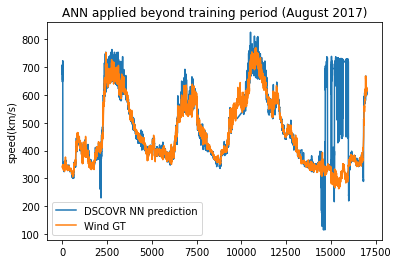

In [93]:
plt.plot(Predictions_August, label='DSCOVR NN prediction')
plt.plot(Wind_input_August_warped, label='Wind GT')
plt.title('ANN applied beyond training period (August 2017)')
plt.savefig('speed_August_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

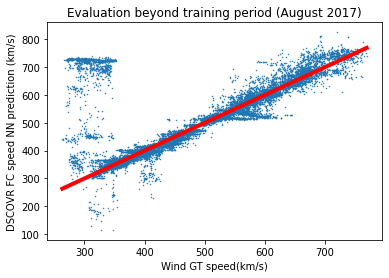

In [94]:
plt.plot(Wind_input_August_warped, Predictions_August, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (August 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_August_warped), np.amax(Wind_input_August_warped)],[np.amin(Wind_input_August_warped), np.amax(Wind_input_August_warped)], color='red', linewidth=4)
plt.savefig('speed-August_prediction_2017.png')

Mean err %:  35.08873417398919
Median err %:  10.019132812499947
stddev: 90.18301942892114


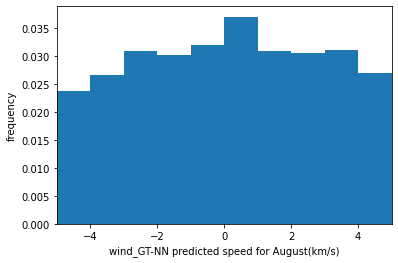

In [95]:
perr_NN_August = 100.*(Wind_input_August_warped-Predictions_August)/Wind_input_August_warped
tk_NN_August=np.where(Wind_input_August_warped > 0.1)
arr_perr_NN_August = (perr_NN_August)[tk_NN_August]
arr_regular_NN_August=(Wind_input_August_warped-Predictions_August)
m_NN_August=np.mean((arr_regular_NN_August))
sd_NN_August=np.std((arr_regular_NN_August))


plt.hist(arr_regular_NN_August, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_August, color='k', linestyle='dashed')
plt.axvline(m_NN_August+sd_NN_August, color='y', linestyle='dashed')
plt.axvline(m_NN_August-sd_NN_August, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for August(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-August_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_August)))
print('Median err %: ', np.median(abs(arr_regular_NN_August)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_August)

## comparison with science data for August

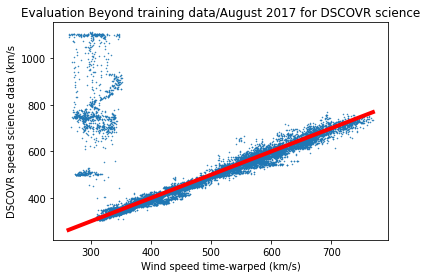

In [96]:
plt.plot(Wind_input_August_warped, DSCOVR_science_August[mask_August.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/August 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_August_warped), np.amax(Wind_input_August_warped)],[np.amin(Wind_input_August_warped), np.amax(Wind_input_August_warped)], color='red', linewidth=4)

plt.savefig('speed-August_science_2017.png')

Mean err %:  142.7788036424009
Median err %:  114.54450000000003
stddev: 184.54576391151585


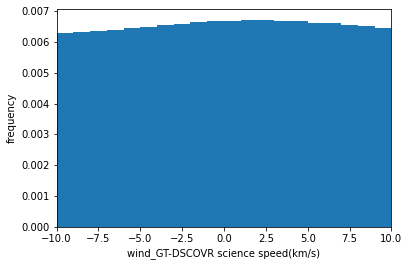

In [97]:
DSCOVR_science_August=np.transpose([np.abs(ddata_science['vp'][114000:130999])]) #May DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_August=np.where((Wind_input_August_warped > 0.1) & ((Wind_input_August_warped-DSCOVR_science_August)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_August=((Wind_input_August_warped-DSCOVR_science_August))[tk_science_August]
m_regular_science_August=np.mean((arr_regular_science_August))
sd_regular_science_August=np.std((arr_regular_science_August))

plt.hist(arr_regular_science_August, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_August, color='k', linestyle='dashed')
plt.axvline(m_regular_science_August+sd_regular_science_August, color='y', linestyle='dashed')
plt.axvline(m_regular_science_August-sd_regular_science_August, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-August_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_August)))
print('Median err %: ', np.median(abs(arr_regular_science_August)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_August)

## September

In [98]:
## September

DSCOVR_input_September, Wind_input_September=input_prep_func(ddata, Wind_speed.values, 131000, 146000)
query1_September, template_September, alignment_wd_September, ind_September=DTW_function(wdata, ddata, 131000, 146000)
Wind_input_September_warped=Wind_input_September[ind_September]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_August_final=PredictorScalerFit.transform(DSCOVR_input_August)


Wind_input_August_warped=Wind_input_August_warped.reshape(-1,1)
Wind_input_August_warped_final=TargetVarScalerFit.transform(Wind_input_August_warped)

mask_August_flat = mask_August.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_August_final = DSCOVR_input_August_final[mask_August_flat]




#18 is the best so far
opt_6 = keras.optimizers.Adam(learning_rate=1e-35)
July_model.compile(loss='mean_squared_error', optimizer=opt_6)

July_model.fit(DSCOVR_input_August_final, Wind_input_August_warped_final, batch_size = 20, epochs = 50, verbose=1)
July_model.save('saved_model_August')

August_model = load_model('saved_model_August')






# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_September_final=PredictorScalerFit.transform(DSCOVR_input_September)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_September_regression_ = August_model.predict(DSCOVR_input_September_final)

# Scaling the data back to original scale for regression predictions
Predictions_September_regression = TargetVarScalerFit.inverse_transform(Predictions_September_regression_)


Epoch 1/50
850/850 [==============================] - 4s 4ms/step - loss: 0.6140
Epoch 2/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 3/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 4/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 5/50
850/850 [==============================] - 4s 4ms/step - loss: 0.6140
Epoch 6/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 7/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 8/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 9/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 10/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 11/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 12/50
850/850 [==============================] - 3s 4ms/step - loss: 0.6140
Epoch 13/50
850/850 [====

850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 40/50
850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 41/50
850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 42/50
850/850 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 43/50
850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 44/50
850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 45/50
850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 46/50
850/850 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 47/50
850/850 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 48/50
850/850 [==============================] - 5s 5ms/step 

In [100]:
mask_September=(Predictions_September_regression >= 1) & (Predictions_September_regression<=850)
Predictions_September=Predictions_September_regression[mask_September]
Wind_input_September_warped=Wind_input_September_warped[mask_September]

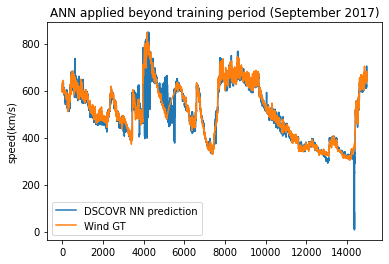

In [101]:
plt.plot(Predictions_September, label='DSCOVR NN prediction')
plt.plot(Wind_input_September_warped, label='Wind GT')
plt.title('ANN applied beyond training period (September 2017)')
plt.savefig('speed_September_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

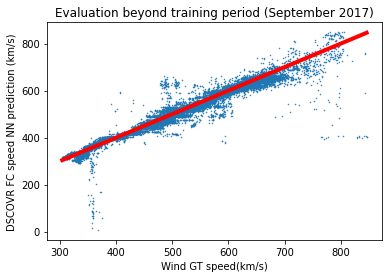

In [102]:
plt.plot(Wind_input_September_warped, Predictions_September, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (September 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_September_warped), np.amax(Wind_input_September_warped)],[np.amin(Wind_input_September_warped), np.amax(Wind_input_September_warped)], color='red', linewidth=4)
plt.savefig('speed-September_prediction_2017.png')

Mean err %:  16.94056678035928
Median err %:  10.622472656250011
stddev: 31.070180877801256


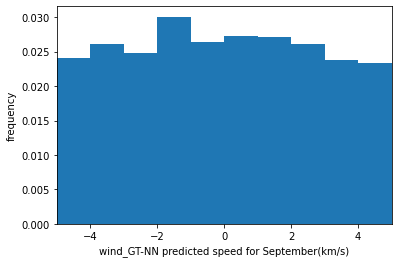

In [103]:
perr_NN_September = 100.*(Wind_input_September_warped-Predictions_September)/Wind_input_September_warped
tk_NN_September=np.where(Wind_input_September_warped > 0.1)
arr_perr_NN_September = (perr_NN_September)[tk_NN_September]
arr_regular_NN_September=(Wind_input_September_warped-Predictions_September)
m_NN_September=np.mean((arr_regular_NN_September))
sd_NN_September=np.std((arr_regular_NN_September))


plt.hist(arr_regular_NN_September, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_September, color='k', linestyle='dashed')
plt.axvline(m_NN_September+sd_NN_September, color='y', linestyle='dashed')
plt.axvline(m_NN_September-sd_NN_September, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for September(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-September_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_September)))
print('Median err %: ', np.median(abs(arr_regular_NN_September)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_September)

## comparison with science data for September

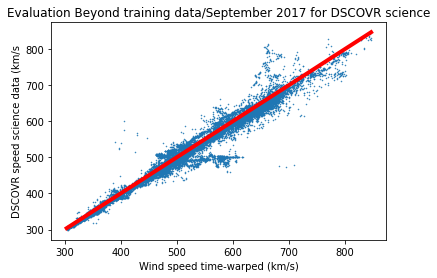

In [104]:
plt.plot(Wind_input_September_warped, DSCOVR_science_September[mask_September.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/September 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_September_warped), np.amax(Wind_input_September_warped)],[np.amin(Wind_input_September_warped), np.amax(Wind_input_September_warped)], color='red', linewidth=4)

plt.savefig('speed-September_science_2017.png')

Mean err %:  133.63051055708706
Median err %:  119.32799999999997
stddev: 164.51720122714676


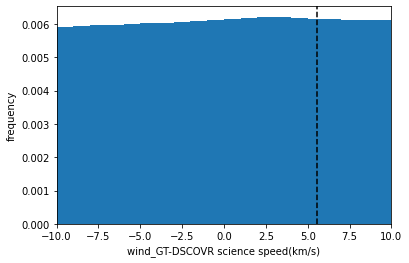

In [105]:
DSCOVR_science_September=np.transpose([np.abs(ddata_science['vp'][131000: 145999])]) #September DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_September=np.where((Wind_input_September_warped > 0.1) & ((Wind_input_September_warped-DSCOVR_science_September)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_September=((Wind_input_September_warped-DSCOVR_science_September))[tk_science_September]
m_regular_science_September=np.mean((arr_regular_science_September))
sd_regular_science_September=np.std((arr_regular_science_September))

plt.hist(arr_regular_science_September, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_September, color='k', linestyle='dashed')
plt.axvline(m_regular_science_September+sd_regular_science_September, color='y', linestyle='dashed')
plt.axvline(m_regular_science_September-sd_regular_science_September, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-September_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_September)))
print('Median err %: ', np.median(abs(arr_regular_science_September)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_September)

## October

In [106]:
## October

DSCOVR_input_October, Wind_input_October=input_prep_func(ddata, Wind_speed.values, 146000, 164000)
query1_October, template_October, alignment_wd_October, ind_October=DTW_function(wdata, ddata, 146000, 164000)
Wind_input_October_warped=Wind_input_October[ind_October]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_September_final=PredictorScalerFit.transform(DSCOVR_input_September)


Wind_input_September_warped=Wind_input_September_warped.reshape(-1,1)
Wind_input_September_warped_final=TargetVarScalerFit.transform(Wind_input_September_warped)

mask_September_flat = mask_September.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_September_final = DSCOVR_input_September_final[mask_September_flat]



#18 is the best so far
opt_7 = keras.optimizers.Adam(learning_rate=1e-39)
August_model.compile(loss='mean_squared_error', optimizer=opt_7)

August_model.fit(DSCOVR_input_September_final, Wind_input_September_warped_final, batch_size = 20, epochs = 50, verbose=1)
August_model.save('saved_model_September')

September_model = load_model('saved_model_September')






# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_October_final=PredictorScalerFit.transform(DSCOVR_input_October)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_October_regression_ = September_model.predict(DSCOVR_input_October_final)

# Scaling the data back to original scale for regression predictions
Predictions_October_regression = TargetVarScalerFit.inverse_transform(Predictions_October_regression_)


Epoch 1/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 2/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 3/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 4/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 5/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 6/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 7/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 8/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 9/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 10/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 11/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 12/50
749/749 [==============================] - 3s 4ms/step - loss: 0.0716
Epoch 13/50
749/749 [====

In [108]:
mask_October=(Predictions_October_regression >= 1) & (Predictions_October_regression<=850)
Predictions_October=Predictions_October_regression[mask_October]
Wind_input_October_warped=Wind_input_October_warped[mask_October]

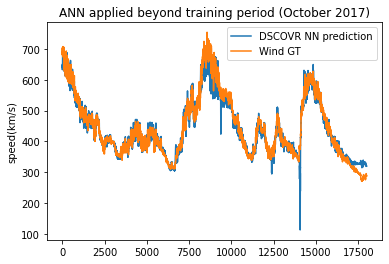

In [109]:
plt.plot(Predictions_October, label='DSCOVR NN prediction')
plt.plot(Wind_input_October_warped, label='Wind GT')
plt.title('ANN applied beyond training period (October 2017)')
plt.savefig('speed_October_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

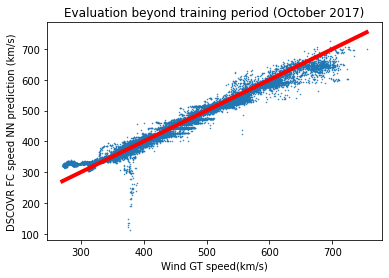

In [110]:
plt.plot(Wind_input_October_warped, Predictions_October, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (October 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_October_warped), np.amax(Wind_input_October_warped)],[np.amin(Wind_input_October_warped), np.amax(Wind_input_October_warped)], color='red', linewidth=4)
plt.savefig('speed-October_prediction_2017.png')

Mean err %:  12.630729825459053
Median err %:  8.148388183593738
stddev: 19.11279848008703


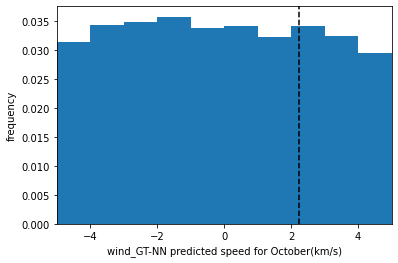

In [111]:
perr_NN_October = 100.*(Wind_input_October_warped-Predictions_October)/Wind_input_October_warped
tk_NN_October=np.where(Wind_input_October_warped > 0.1)
arr_perr_NN_October = (perr_NN_October)[tk_NN_October]
arr_regular_NN_October=(Wind_input_October_warped-Predictions_October)
m_NN_October=np.mean((arr_regular_NN_October))
sd_NN_October=np.std((arr_regular_NN_October))


plt.hist(arr_regular_NN_October, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_October, color='k', linestyle='dashed')
plt.axvline(m_NN_October+sd_NN_October, color='y', linestyle='dashed')
plt.axvline(m_NN_October-sd_NN_October, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for October(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-October_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_October)))
print('Median err %: ', np.median(abs(arr_regular_NN_October)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_October)

## comparison with science data for October

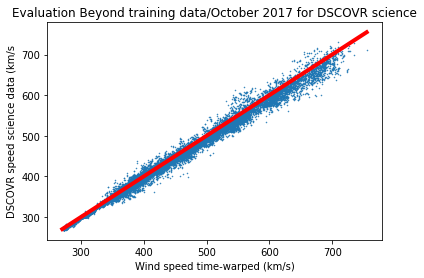

In [112]:
plt.plot(Wind_input_October_warped, DSCOVR_science_October[mask_October.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/October 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_October_warped), np.amax(Wind_input_October_warped)],[np.amin(Wind_input_October_warped), np.amax(Wind_input_October_warped)], color='red', linewidth=4)

plt.savefig('speed-October_science_2017.png')

Mean err %:  109.25757272888387
Median err %:  88.64249999999998
stddev: 138.51676265713124


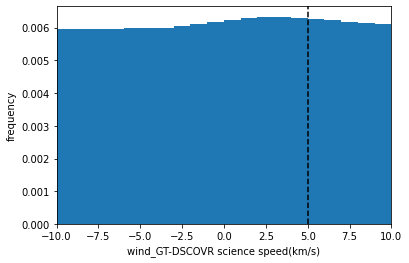

In [113]:
DSCOVR_science_October=np.transpose([np.abs(ddata_science['vp'][146000:163999])]) #September DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_October=np.where((Wind_input_October_warped > 0.1) & ((Wind_input_October_warped-DSCOVR_science_October)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_October=((Wind_input_October_warped-DSCOVR_science_October))[tk_science_October]
m_regular_science_October=np.mean((arr_regular_science_October))
sd_regular_science_October=np.std((arr_regular_science_October))

plt.hist(arr_regular_science_October, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_October, color='k', linestyle='dashed')
plt.axvline(m_regular_science_October+sd_regular_science_October, color='y', linestyle='dashed')
plt.axvline(m_regular_science_October-sd_regular_science_October, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-October_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_October)))
print('Median err %: ', np.median(abs(arr_regular_science_October)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_October)

## November

In [114]:
## November

DSCOVR_input_November, Wind_input_November=input_prep_func(ddata, Wind_speed.values, 164000, 180000)
query1_November, template_November, alignment_wd_November, ind_November=DTW_function(wdata, ddata, 164000, 180000)
Wind_input_November_warped=Wind_input_November[ind_November]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_October_final=PredictorScalerFit.transform(DSCOVR_input_October)


Wind_input_October_warped=Wind_input_October_warped.reshape(-1,1)
Wind_input_October_warped_final=TargetVarScalerFit.transform(Wind_input_October_warped)

mask_October_flat = mask_October.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_October_final = DSCOVR_input_October_final[mask_October_flat]



#18 is the best so far
opt_8 = keras.optimizers.Adam(learning_rate=1e-42)
September_model.compile(loss='mean_squared_error', optimizer=opt_8)

September_model.fit(DSCOVR_input_October_final, Wind_input_October_warped_final, batch_size = 20, epochs = 50, verbose=1)
September_model.save('saved_model_October')

October_model = load_model('saved_model_October')










# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_November_final=PredictorScalerFit.transform(DSCOVR_input_November)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_November_regression_ = October_model.predict(DSCOVR_input_November_final)

# Scaling the data back to original scale for regression predictions
Predictions_November_regression = TargetVarScalerFit.inverse_transform(Predictions_November_regression_)


Epoch 1/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 2/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 3/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 4/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 5/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 6/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 7/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 8/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 9/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 10/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 11/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 12/50
900/900 [==============================] - 4s 4ms/step - loss: 0.0266
Epoch 13/50
900/900 [====

900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 40/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 41/50
900/900 [==============================] - 1044s 1s/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 42/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 43/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 44/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 45/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 46/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 47/50
900/900 [==============================] - 5s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 48/50
900/900 [==============================] - 5s 5ms/ste

In [116]:
mask_November=(Predictions_November_regression >= 1) & (Predictions_November_regression<=850)
Predictions_November=Predictions_November_regression[mask_November]
Wind_input_November_warped=Wind_input_November_warped[mask_November]

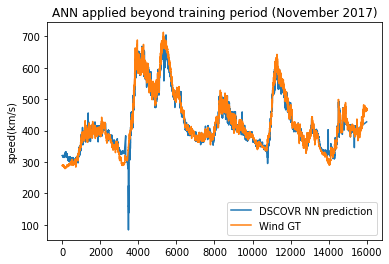

In [117]:
plt.plot(Predictions_November, label='DSCOVR NN prediction')
plt.plot(Wind_input_November_warped, label='Wind GT')
plt.title('ANN applied beyond training period (November 2017)')
plt.savefig('speed_November_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

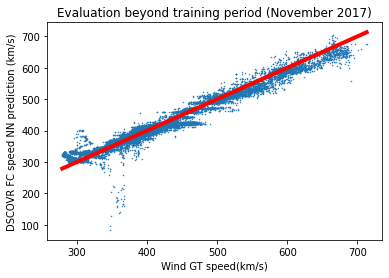

In [118]:
plt.plot(Wind_input_November_warped, Predictions_November, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (November 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_November_warped), np.amax(Wind_input_November_warped)],[np.amin(Wind_input_November_warped), np.amax(Wind_input_November_warped)], color='red', linewidth=4)
plt.savefig('speed-November_prediction_2017.png')

Mean err %:  12.843218662882684
Median err %:  9.100565429687492
stddev: 19.010283934549417


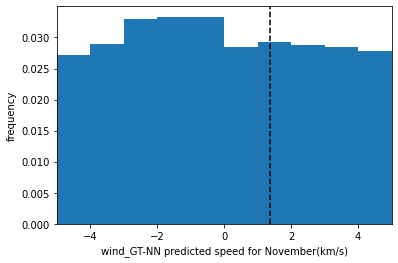

In [119]:
perr_NN_November = 100.*(Wind_input_November_warped-Predictions_November)/Wind_input_November_warped
tk_NN_November=np.where(Wind_input_November_warped > 0.1)
arr_perr_NN_November = (perr_NN_November)[tk_NN_November]
arr_regular_NN_November=(Wind_input_November_warped-Predictions_November)
m_NN_November=np.mean((arr_regular_NN_November))
sd_NN_November=np.std((arr_regular_NN_November))


plt.hist(arr_regular_NN_November, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_November, color='k', linestyle='dashed')
plt.axvline(m_NN_November+sd_NN_November, color='y', linestyle='dashed')
plt.axvline(m_NN_November-sd_NN_November, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for November(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-November_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_November)))
print('Median err %: ', np.median(abs(arr_regular_NN_November)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_November)

## comparison with science data for November

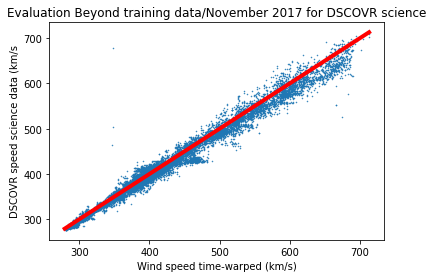

In [120]:
plt.plot(Wind_input_November_warped, DSCOVR_science_November[mask_November.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/November 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_November_warped), np.amax(Wind_input_November_warped)],[np.amin(Wind_input_November_warped), np.amax(Wind_input_November_warped)], color='red', linewidth=4)

plt.savefig('speed-November_science_2017.png')

Mean err %:  97.28332172653997
Median err %:  75.875
stddev: 126.36377219468389


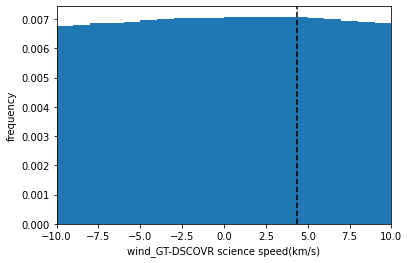

In [121]:
DSCOVR_science_November=np.transpose([np.abs(ddata_science['vp'][164000: 179999])]) #September DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_November=np.where((Wind_input_November_warped > 0.1) & ((Wind_input_November_warped-DSCOVR_science_November)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_November=((Wind_input_November_warped-DSCOVR_science_November))[tk_science_November]
m_regular_science_November=np.mean((arr_regular_science_November))
sd_regular_science_November=np.std((arr_regular_science_November))

plt.hist(arr_regular_science_November, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_November, color='k', linestyle='dashed')
plt.axvline(m_regular_science_November+sd_regular_science_November, color='y', linestyle='dashed')
plt.axvline(m_regular_science_November-sd_regular_science_November, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-November_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_November)))
print('Median err %: ', np.median(abs(arr_regular_science_November)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_November)

## December

In [122]:
## December

DSCOVR_input_December, Wind_input_December=input_prep_func(ddata, Wind_speed.values, 180000, 197100)
query1_December, template_December, alignment_wd_December, ind_December=DTW_function(wdata, ddata, 180000, 197100)
Wind_input_December_warped=Wind_input_December[ind_December]

# Generating the standardized values of DSCOVR_input and Wind_input for March
DSCOVR_input_November_final=PredictorScalerFit.transform(DSCOVR_input_November)



Wind_input_November_warped=Wind_input_November_warped.reshape(-1,1)
Wind_input_November_warped_final=TargetVarScalerFit.transform(Wind_input_November_warped)

mask_November_flat = mask_November.flatten()  #so that it matches dimension 50
# Now use the flattened mask for indexing
DSCOVR_input_November_final = DSCOVR_input_November_final[mask_November_flat]



#18 is the best so far
opt_9 = keras.optimizers.Adam(learning_rate=1e-42)
October_model.compile(loss='mean_squared_error', optimizer=opt_9)

October_model.fit(DSCOVR_input_November_final, Wind_input_November_warped_final, batch_size = 20, epochs = 50, verbose=1)
October_model.save('saved_model_November')

November_model = load_model('saved_model_November')







# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_December_final=PredictorScalerFit.transform(DSCOVR_input_December)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

# Generate Predictions on testing data for April using the regression model
Predictions_December_regression_ = November_model.predict(DSCOVR_input_December_final)

# Scaling the data back to original scale for regression predictions
Predictions_December_regression = TargetVarScalerFit.inverse_transform(Predictions_December_regression_)


Epoch 1/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 2/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 3/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 4/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 5/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 6/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 7/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 8/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 9/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 10/50
800/800 [==============================] - 922s 1s/step - loss: 0.0261
Epoch 11/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 12/50
800/800 [==============================] - 3s 4ms/step - loss: 0.0261
Epoch 13/50
800/800 [===

Epoch 39/50
800/800 [==============================] - 952s 1s/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 40/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 41/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 42/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 43/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 44/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 45/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 46/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 47/50
800/800 [==============================] - 4s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Epoch 48/50
800/800 [==============================] -

In [124]:
mask_December=(Predictions_December_regression >= 1) & (Predictions_December_regression<=850)
Predictions_December=Predictions_December_regression[mask_December]
Wind_input_December_warped=Wind_input_December_warped[mask_December]

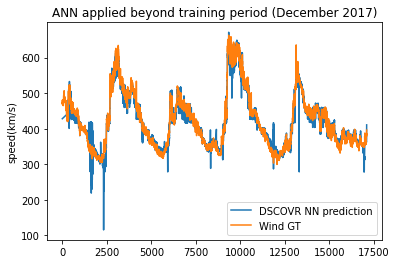

In [125]:
plt.plot(Predictions_December, label='DSCOVR NN prediction')
plt.plot(Wind_input_December_warped, label='Wind GT')
plt.title('ANN applied beyond training period (December 2017)')
plt.savefig('speed_December_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

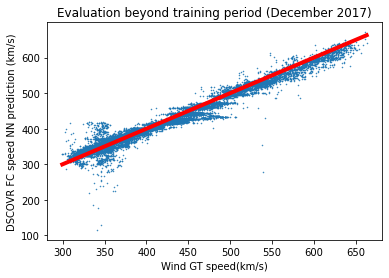

In [126]:
plt.plot(Wind_input_December_warped, Predictions_December, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (December 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_December_warped), np.amax(Wind_input_December_warped)],[np.amin(Wind_input_December_warped), np.amax(Wind_input_December_warped)], color='red', linewidth=4)
plt.savefig('speed-December_prediction_2017.png')

Mean err %:  10.916484851742203
Median err %:  8.114157104492193
stddev: 15.660990558997833


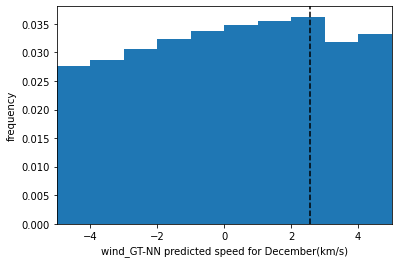

In [127]:
perr_NN_December = 100.*(Wind_input_December_warped-Predictions_December)/Wind_input_December_warped
tk_NN_December=np.where(Wind_input_December_warped > 0.1)
arr_perr_NN_December = (perr_NN_December)[tk_NN_December]
arr_regular_NN_December=(Wind_input_December_warped-Predictions_December)
m_NN_December=np.mean((arr_regular_NN_December))
sd_NN_December=np.std((arr_regular_NN_December))


plt.hist(arr_regular_NN_December, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_December, color='k', linestyle='dashed')
plt.axvline(m_NN_December+sd_NN_December, color='y', linestyle='dashed')
plt.axvline(m_NN_December-sd_NN_December, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.xlabel('wind_GT-NN predicted speed for December(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-December_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_December)))
print('Median err %: ', np.median(abs(arr_regular_NN_December)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_December)

## comparison with science data for December

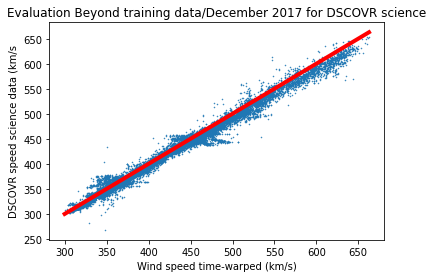

In [128]:
#plt.plot(Wind_input_December_warped)
#plt.plot(np.abs(ddata_science['vp'][136000:145999]))
#plt.plot(Wind_input_December_warped, np.abs(ddata_science['vp'][180000, 197099]), marker='.', markersize=1, linestyle = ' ')
plt.plot(Wind_input_December_warped, DSCOVR_science_December[mask_December.squeeze()], marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind speed time-warped (km/s)")
plt.ylabel("DSCOVR speed science data (km/s")
plt.title('Evaluation Beyond training data/December 2017 for DSCOVR science')
#plt.xlim(np.amin(warped_speed), np.amax(warped_speed))
#plt.ylim(np.amin(warped_speed), np.amax(warped_speed))
plt.plot([np.amin(Wind_input_December_warped), np.amax(Wind_input_December_warped)],[np.amin(Wind_input_December_warped), np.amax(Wind_input_December_warped)], color='red', linewidth=4)

plt.savefig('speed-December_science_2017.png')

Mean err %:  84.87385257670432
Median err %:  71.00050000000005
stddev: 107.71171362654574


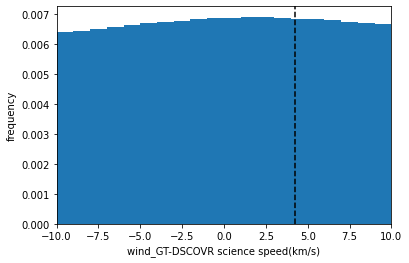

In [129]:
DSCOVR_science_December=np.transpose([np.abs(ddata_science['vp'][180000: 197099])]) #September DSCOVR speed

#perr_science_March = 100.*(Wind_input_March_warped-dd_science_March.values)/Wind_input_March_warped
tk_science_December=np.where((Wind_input_December_warped > 0.1) & ((Wind_input_December_warped-DSCOVR_science_December)!=0))

#arr_perr_science_March = (perr_science_March)[tk_science_March]

arr_regular_science_December=((Wind_input_December_warped-DSCOVR_science_December))[tk_science_December]
m_regular_science_December=np.mean((arr_regular_science_December))
sd_regular_science_December=np.std((arr_regular_science_December))

plt.hist(arr_regular_science_December, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_regular_science_December, color='k', linestyle='dashed')
plt.axvline(m_regular_science_December+sd_regular_science_December, color='y', linestyle='dashed')
plt.axvline(m_regular_science_December-sd_regular_science_December, color='y', linestyle='dashed')


plt.xlim(-10,10)
#plt.yscale('log')
plt.xlabel('wind_GT-DSCOVR science speed(km/s)')
plt.ylabel('frequency')
plt.savefig('Error-speed-December_science_2017.png')
print('Mean err %: ', np.mean(abs(arr_regular_science_December)))
print('Median err %: ', np.median(abs(arr_regular_science_December)))
#print('Most probable err %: ', statistics.mode(abs(arr_regular_science_March)))

print('stddev:',sd_regular_science_December)

In [131]:
stddev_A=[sd_NN, sd_NN_March, sd_NN_April, sd_NN_May, sd_NN_June, sd_NN_July, sd_NN_August, sd_NN_September, sd_NN_October, sd_NN_November, sd_NN_December]

In [132]:
stddev_science=[sd_regular_science, sd_regular_science_March, sd_regular_science_April, sd_regular_science_May, sd_regular_science_June, sd_regular_science_July, sd_regular_science_August, sd_regular_science_September, sd_regular_science_October, sd_regular_science_November, sd_regular_science_December]

In [133]:
stddev_A

[15.135217931928809,
 38.23923616983465,
 23.901204806673498,
 36.9941324015263,
 50.20523913469306,
 43.5919273423902,
 90.18301942892114,
 31.070180877801256,
 19.11279848008703,
 19.010283934549417,
 15.660990558997833]

In [134]:
stddev_science

[21.055765749617947,
 179.73326968675704,
 151.83945204310078,
 130.90724443539025,
 102.95394579799637,
 141.51823280467445,
 184.54576391151585,
 164.51720122714676,
 138.51676265713124,
 126.36377219468389,
 107.71171362654574]

### MAE

In [135]:
from sklearn.metrics import mean_absolute_error
#mean_absolute_error(y_true, y_pred)

Jan_Feb_MAE=mean_absolute_error(TestingData_GT.tolist(), TestingData_Predicted.tolist())
March_MAE=mean_absolute_error((np.concatenate(Wind_input_March_warped)).tolist(), Predictions_March.tolist())
April_MAE=mean_absolute_error((np.concatenate(Wind_input_April_warped)).tolist(), Predictions_April.tolist())
May_MAE=mean_absolute_error((np.concatenate(Wind_input_May_warped)).tolist(), Predictions_May.tolist())
June_MAE=mean_absolute_error((np.concatenate(Wind_input_June_warped)).tolist(), Predictions_June.tolist())
July_MAE=mean_absolute_error((np.concatenate(Wind_input_July_warped)).tolist(), Predictions_July.tolist())
August_MAE=mean_absolute_error((np.concatenate(Wind_input_August_warped)).tolist(), Predictions_August.tolist())
September_MAE=mean_absolute_error((np.concatenate(Wind_input_September_warped)).tolist(), Predictions_September.tolist())
October_MAE=mean_absolute_error((np.concatenate(Wind_input_October_warped)).tolist(), Predictions_October.tolist())
November_MAE=mean_absolute_error((np.concatenate(Wind_input_November_warped)).tolist(), Predictions_November.tolist())
December_MAE=mean_absolute_error(Wind_input_December_warped.tolist(), Predictions_December.tolist())

In [136]:
Jan_Feb_science_MAE=mean_absolute_error(warped_speed_Jan_Feb.tolist(), DSCOVR_science_Jan_Feb.tolist())
March_science_MAE=mean_absolute_error((np.concatenate(Wind_input_March_warped)).tolist(), DSCOVR_science_March[mask_March.squeeze()].tolist())
April_science_MAE=mean_absolute_error((np.concatenate(Wind_input_April_warped)).tolist(), DSCOVR_science_April[mask_April.squeeze()].tolist())
May_science_MAE=mean_absolute_error((np.concatenate(Wind_input_May_warped)).tolist(), DSCOVR_science_May[mask_May.squeeze()].tolist())
June_science_MAE=mean_absolute_error((np.concatenate(Wind_input_June_warped)).tolist(), DSCOVR_science_June[mask_June.squeeze()].tolist())
July_science_MAE=mean_absolute_error((np.concatenate(Wind_input_July_warped)).tolist(), DSCOVR_science_July[mask_July.squeeze()].tolist())
August_science_MAE=mean_absolute_error((np.concatenate(Wind_input_August_warped)).tolist(), DSCOVR_science_August[mask_August.squeeze()].tolist())
September_science_MAE=mean_absolute_error((np.concatenate(Wind_input_September_warped)).tolist(), DSCOVR_science_September[mask_September.squeeze()].tolist())
October_science_MAE=mean_absolute_error((np.concatenate(Wind_input_October_warped)).tolist(), DSCOVR_science_October[mask_October.squeeze()].tolist())
November_science_MAE=mean_absolute_error((np.concatenate(Wind_input_November_warped)).tolist(), DSCOVR_science_November[mask_November.squeeze()].tolist())
December_science_MAE=mean_absolute_error(Wind_input_December_warped.tolist(), DSCOVR_science_December[mask_December.squeeze()].tolist())

In [137]:
np.average([Jan_Feb_MAE, March_MAE, April_MAE, May_MAE, June_MAE, July_MAE, August_MAE, September_MAE, October_MAE, November_MAE, December_MAE])


16.530603200319657

In [138]:
np.average([Jan_Feb_science_MAE, March_science_MAE, April_science_MAE, May_science_MAE, June_science_MAE, July_science_MAE, August_science_MAE, September_science_MAE, October_science_MAE, November_science_MAE, December_science_MAE])


13.03618424566327

### RMSE

In [139]:
from sklearn.metrics import mean_squared_error
#mean_squared_error

Jan_Feb_RMAE=np.sqrt(mean_squared_error(TestingData_GT.tolist(), TestingData_Predicted.tolist()))
March_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_March_warped)).tolist(), Predictions_March.tolist()))
April_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_April_warped)).tolist(), Predictions_April.tolist()))
May_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_May_warped)).tolist(), Predictions_May.tolist()))
June_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_June_warped)).tolist(), Predictions_June.tolist()))
July_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_July_warped)).tolist(), Predictions_July.tolist()))
August_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_August_warped)).tolist(), Predictions_August.tolist()))
September_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_September_warped)).tolist(), Predictions_September.tolist()))
October_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_October_warped)).tolist(), Predictions_October.tolist()))
November_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_November_warped)).tolist(), Predictions_November.tolist()))
December_RMAE=np.sqrt(mean_squared_error(Wind_input_December_warped.tolist(), Predictions_December.tolist()))

In [140]:
Jan_Feb_science_RMAE=np.sqrt(mean_squared_error(warped_speed_Jan_Feb.tolist(), DSCOVR_science_Jan_Feb.tolist()))
March_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_March_warped)).tolist(), DSCOVR_science_March[mask_March.squeeze()].tolist()))
April_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_April_warped)).tolist(), DSCOVR_science_April[mask_April.squeeze()].tolist()))
May_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_May_warped)).tolist(), DSCOVR_science_May[mask_May.squeeze()].tolist()))
June_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_June_warped)).tolist(), DSCOVR_science_June[mask_June.squeeze()].tolist()))
July_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_July_warped)).tolist(), DSCOVR_science_July[mask_July.squeeze()].tolist()))
August_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_August_warped)).tolist(), DSCOVR_science_August[mask_August.squeeze()].tolist()))
September_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_September_warped)).tolist(), DSCOVR_science_September[mask_September.squeeze()].tolist()))
October_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_October_warped)).tolist(), DSCOVR_science_October[mask_October.squeeze()].tolist()))
November_science_RMAE=np.sqrt(mean_squared_error((np.concatenate(Wind_input_November_warped)).tolist(), DSCOVR_science_November[mask_November.squeeze()].tolist()))
December_science_RMAE=np.sqrt(mean_squared_error(Wind_input_December_warped.tolist(), DSCOVR_science_December[mask_December.squeeze()].tolist()))

In [141]:
RMSE_A=[Jan_Feb_RMAE, March_RMAE, April_RMAE, May_RMAE, June_RMAE, July_RMAE, August_RMAE, September_RMAE, October_RMAE, November_RMAE, December_RMAE]
np.average([Jan_Feb_RMAE, March_RMAE, April_RMAE, May_RMAE, June_RMAE, July_RMAE, August_RMAE, September_RMAE, October_RMAE, November_RMAE, December_RMAE])

35.27830319254728

In [142]:
RMSE_A

[15.19056280874698,
 38.70066268913017,
 24.278810814099415,
 37.713244003701455,
 50.25267036834078,
 43.76564625986209,
 92.42894739254156,
 31.557548792257883,
 19.243973273869006,
 19.05923409689146,
 15.870034618579247]

In [143]:
RMSE_science=[Jan_Feb_science_RMAE, March_science_RMAE, April_science_RMAE, May_science_RMAE, June_science_RMAE, July_science_RMAE, August_science_RMAE, September_science_RMAE, October_science_RMAE, November_science_RMAE, December_science_RMAE]
np.average([Jan_Feb_science_RMAE, March_science_RMAE, April_science_RMAE, May_science_RMAE, June_science_RMAE, July_science_RMAE, August_science_RMAE, September_science_RMAE, October_science_RMAE, November_science_RMAE, December_science_RMAE])

27.61301963889454

In [144]:
print('Jan_Feb:', np.where(TestingData_Predicted<0))
print('March:', np.where(Predictions_March<0))
print('April:', np.where(Predictions_April<0))
print('May:', np.where(Predictions_May<0))
print('June:', np.where(Predictions_June<0))
print('July:', np.where(Predictions_July<0))
print('August:', np.where(Predictions_August<0))
print('September:', np.where(Predictions_September<0))
print('October:', np.where(Predictions_October<0))
print('November:', np.where(Predictions_November<0))
print('December:', np.where(Predictions_December<0))

Jan_Feb: (array([], dtype=int64),)
March: (array([], dtype=int64),)
April: (array([], dtype=int64),)
May: (array([], dtype=int64),)
June: (array([], dtype=int64),)
July: (array([], dtype=int64),)
August: (array([], dtype=int64),)
September: (array([], dtype=int64),)
October: (array([], dtype=int64),)
November: (array([], dtype=int64),)
December: (array([], dtype=int64),)


In [145]:
np.average(stddev_A)

34.82765736976392

In [146]:
np.average(stddev_science)

131.78755673950548

In [147]:
export_stddev = pd.DataFrame(data={"speed std A 2017": stddev_A, "speed std science 2017": stddev_science})
export_stddev.to_csv("speed_stddev_A_export_2017.csv", sep=',',index=False)

In [148]:
export_RMSE = pd.DataFrame(data={"speed RMSE A 2017": RMSE_A, "speed RMSE science 2017": RMSE_science})
export_RMSE.to_csv("speed_RMSE_A_export_2017.csv", sep=',',index=False)

In [ ]:
end

## Exporting to csv file

In [ ]:
Jan_Feb_output=[TestingData_GT.tolist(), TestingData_Predicted.tolist()]
March_output=[(np.concatenate(Wind_input_March_warped)).tolist(), (np.concatenate(Predictions_March)).tolist()]
April_output=[(np.concatenate(Wind_input_April_warped)).tolist(), (np.concatenate(Predictions_April)).tolist()]
May_output=[(np.concatenate(Wind_input_May_warped)).tolist(), (np.concatenate(Predictions_May)).tolist()]
June_output=[(np.concatenate(Wind_input_June_warped)).tolist(), (np.concatenate(Predictions_June)).tolist()]
July_output=[(np.concatenate(Wind_input_July_warped)).tolist(), (np.concatenate(Predictions_July)).tolist()]
August_output=[(np.concatenate(Wind_input_August_warped)).tolist(), (np.concatenate(Predictions_August)).tolist()]
September_output=[(np.concatenate(Wind_input_September_warped)).tolist(), (np.concatenate(Predictions_September)).tolist()]
October_output=[(np.concatenate(Wind_input_October_warped)).tolist(), (np.concatenate(Predictions_October)).tolist()]
November_output=[(np.concatenate(Wind_input_November_warped)).tolist(), (np.concatenate(Predictions_November)).tolist()]
December_output=[(np.concatenate(Wind_input_December_warped)).tolist(), (np.concatenate(Predictions_December)).tolist()]

In [ ]:
import csv

# Define column names
column_names = ['Wind_Jan_Feb', 'Prediction_Jan_Feb']

# Open the CSV file in append mode with tab as the delimiter
with open('Jan_Feb_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*Jan_Feb_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_March', 'Prediction_March']

# Open the CSV file in append mode with tab as the delimiter
with open('March_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*March_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_April', 'Prediction_April']

# Open the CSV file in append mode with tab as the delimiter
with open('April_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*April_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_May', 'Prediction_May']

# Open the CSV file in append mode with tab as the delimiter
with open('May_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*May_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_June', 'Prediction_June']

# Open the CSV file in append mode with tab as the delimiter
with open('June_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*June_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_July', 'Prediction_July']

# Open the CSV file in append mode with tab as the delimiter
with open('July_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*July_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_August', 'Prediction_August']

# Open the CSV file in append mode with tab as the delimiter
with open('August_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*August_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_September', 'Prediction_September']

# Open the CSV file in append mode with tab as the delimiter
with open('September_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*September_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_October', 'Prediction_October']

# Open the CSV file in append mode with tab as the delimiter
with open('October_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*October_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_November', 'Prediction_November']

# Open the CSV file in append mode with tab as the delimiter
with open('November_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*November_output):
        writer.writerow(row)

In [ ]:
import csv

# Define column names
column_names = ['Wind_December', 'Prediction_December']

# Open the CSV file in append mode with tab as the delimiter
with open('December_speed_MethodA_2017_output-file.csv', 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter='\t')

    # Write the column names as the first row
    writer.writerow(column_names)

    # Use zip to transpose the data and write it to the CSV file
    for row in zip(*December_output):
        writer.writerow(row)

In [ ]:
%whos

In [ ]:
from scipy.signal import chirp, find_peaks, peak_widths
peaks, _ = find_peaks(arr_regular)
results_half = peak_widths(arr_regular, peaks, rel_height=0.5)
results_half[0]  # width

results_full = peak_widths(arr_regular, peaks, rel_height=1)
results_full[0]  # widths

plt.plot(arr_regular)
plt.plot(peaks, arr_regular[peaks], "x")
#plt.hlines(*results_half[1:], color="C2")
#plt.hlines(*results_full[1:], color="C3")
plt.show()